# 🧠 NLP Emotion Classification — End-to-End MNC Project
### *Automatically detect human emotions from raw text using Machine Learning & NLP*

---

<div style='background:#1a1a2e; color:#eee; padding:18px; border-radius:10px; font-family:monospace'>

| 📌 Detail         | 📋 Information                                      |
|-------------------|-----------------------------------------------------|
| **Project**       | NLP Text Classification — Emotion Detection        |
| **Dataset**       | Emotion Dataset (Train 16K / Val 2K / Test 2K)     |
| **Target Classes**| Sadness · Joy · Love · Anger · Fear · Surprise     |
| **NLP Techniques**| Bag-of-Words · TF-IDF · N-Grams · Text Cleaning    |
| **ML Models**     | Naive Bayes · Logistic Reg · SVM · Random Forest · Gradient Boosting |
| **Evaluation**    | Accuracy · Precision · Recall · F1 · Confusion Matrix · ROC |

</div>

---

## 🗺️ Project Pipeline

```
┌─────────────────────────────────────────────────────────────────┐
│  STEP 01 ── Import Libraries                                    │
│  STEP 02 ── Load All Three Datasets (Train / Val / Test)        │
│  STEP 03 ── Exploratory Data Analysis (EDA)                     │
│  STEP 04 ── Data Cleaning & Text Preprocessing (NLP Pipeline)   │
│  STEP 05 ── Data Visualization (10+ Professional Charts)        │
│  STEP 06 ── Feature Extraction (Bag-of-Words & TF-IDF)          │
│  STEP 07 ── Model Building & Training (5 Models)                │
│  STEP 08 ── Model Evaluation on Validation Set                  │
│  STEP 09 ── Hyperparameter Tuning (GridSearchCV)                │
│  STEP 10 ── Final Evaluation on Test Set                        │
│  STEP 11 ── Live Prediction Demo                                │
│  STEP 12 ── Save Model & Summary Dashboard                      │
└─────────────────────────────────────────────────────────────────┘
```

---
## 📦 STEP 01 — Import All Required Libraries
> Industry practice: import everything at the top so all dependencies are visible at a glance.

In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              STEP 01 — IMPORT LIBRARIES                     ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Core Data Manipulation ────────────────────────────────────
import numpy as np                          # Numerical operations & arrays
import pandas as pd                         # DataFrame operations

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt             # Base plotting engine
import matplotlib.patches as mpatches       # Custom legend patches
import matplotlib.cm as cm                  # Colour maps
import seaborn as sns                       # Statistical charts
from matplotlib.gridspec import GridSpec    # Complex subplot layouts

# ── Text Processing (Standard Library) ────────────────────────
import re                                   # Regular expressions
import string                               # Punctuation constants
from collections import Counter             # Word frequency counting

# ── Scikit-Learn: Preprocessing ───────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    cross_val_score,                        # K-Fold Cross Validation
    GridSearchCV                            # Hyperparameter tuning
)

# ── Scikit-Learn: NLP Feature Extraction ──────────────────────
from sklearn.feature_extraction.text import (
    CountVectorizer,                        # Bag-of-Words (BoW)
    TfidfVectorizer                         # TF-IDF Vectorizer
)

# ── Scikit-Learn: Machine Learning Models ─────────────────────
from sklearn.naive_bayes     import MultinomialNB           # Best for text (NLP baseline)
from sklearn.linear_model    import LogisticRegression      # Strong probabilistic classifier
from sklearn.svm             import LinearSVC               # SVM — industry standard for NLP
from sklearn.ensemble        import RandomForestClassifier  # Tree ensemble
from sklearn.ensemble        import GradientBoostingClassifier  # Boosted trees

# ── Scikit-Learn: Evaluation Metrics ──────────────────────────
from sklearn.metrics import (
    accuracy_score,                         # Overall accuracy
    classification_report,                  # Precision / Recall / F1 per class
    confusion_matrix,                       # Confusion matrix array
    f1_score,                               # F1 score (macro / weighted)
    precision_score,                        # Precision
    recall_score                            # Recall
)

# ── Pipeline ──────────────────────────────────────────────────
from sklearn.pipeline import Pipeline       # Chain vectorizer + model

# ── Model Persistence ─────────────────────────────────────────
import pickle                               # Save/load trained models
import os                                   # File operations
import warnings
warnings.filterwarnings('ignore')           # Suppress non-critical warnings

# ── Global Display Settings ───────────────────────────────────
pd.set_option('display.max_colwidth',  120) # Show full text in DataFrames
pd.set_option('display.max_columns',   20)  # Show all columns
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Global Plot Settings ──────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'         : 130,
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.titlesize'     : 13,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 11,
})

# ── Emotion Definitions ───────────────────────────────────────
# Map numeric labels → emotion names and colours (used throughout project)
EMOTION_MAP = {
    0: 'Sadness',
    1: 'Joy',
    2: 'Love',
    3: 'Anger',
    4: 'Fear',
    5: 'Surprise'
}

EMOTION_COLORS = {
    'Sadness' : '#5b8dee',   # Blue
    'Joy'     : '#f9ca24',   # Yellow
    'Love'    : '#e84393',   # Pink
    'Anger'   : '#e74c3c',   # Red
    'Fear'    : '#8e44ad',   # Purple
    'Surprise': '#00b894',   # Teal
}

EMOTION_EMOJI = {
    'Sadness' : '😢',
    'Joy'     : '😄',
    'Love'    : '❤️',
    'Anger'   : '😠',
    'Fear'    : '😨',
    'Surprise': '😲',
}

PALETTE = list(EMOTION_COLORS.values())
CLASS_NAMES = list(EMOTION_MAP.values())

print('✅  All libraries imported successfully!')
print(f'   numpy    : {np.__version__}')
print(f'   pandas   : {pd.__version__}')
import sklearn
print(f'   sklearn  : {sklearn.__version__}')
print(f'   seaborn  : {sns.__version__}')
print()
print('🎭  Emotion Classes:')
for k, v in EMOTION_MAP.items():
    emoji = EMOTION_EMOJI[v]
    print(f'   Label {k}  →  {v} {emoji}')

✅  All libraries imported successfully!
   numpy    : 1.26.4
   pandas   : 2.1.4
   sklearn  : 1.4.2
   seaborn  : 0.13.2

🎭  Emotion Classes:
   Label 0  →  Sadness 😢
   Label 1  →  Joy 😄
   Label 2  →  Love ❤️
   Label 3  →  Anger 😠
   Label 4  →  Fear 😨
   Label 5  →  Surprise 😲


---
## 📂 STEP 02 — Load All Three Datasets
> We use the dedicated **Train / Validation / Test** split — best practice for unbiased evaluation.

In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 02 — LOAD TRAIN / VALIDATION / TEST            ║
# ╚══════════════════════════════════════════════════════════════╝

# Load all three CSV files
train_df = pd.read_csv('training.csv')    # Used to TRAIN models
val_df   = pd.read_csv('validation.csv')  # Used to TUNE & SELECT models
test_df  = pd.read_csv('test.csv')        # Used ONLY for final evaluation

# ── Add human-readable emotion column ─────────────────────────
for df in [train_df, val_df, test_df]:
    df['emotion'] = df['label'].map(EMOTION_MAP)  # 0 → 'Sadness', 1 → 'Joy', etc.

# ── Print summary ─────────────────────────────────────────────
print('=' * 60)
print('  DATASETS LOADED SUCCESSFULLY')
print('=' * 60)
print(f'  Training   : {train_df.shape[0]:>6,} rows  ×  {train_df.shape[1]} columns')
print(f'  Validation : {val_df.shape[0]:>6,} rows  ×  {val_df.shape[1]} columns')
print(f'  Test       : {test_df.shape[0]:>6,} rows  ×  {test_df.shape[1]} columns')
print(f'  Total      : {len(train_df)+len(val_df)+len(test_df):>6,} rows')
print('=' * 60)

  DATASETS LOADED SUCCESSFULLY
  Training   : 16,000 rows  ×  3 columns
  Validation :  2,000 rows  ×  3 columns
  Test       :  2,000 rows  ×  3 columns
  Total      : 20,000 rows


In [7]:
# ── Preview training data ─────────────────────────────────────
print('📋  Training Data Sample (first 8 rows):')
train_df.head(8)

📋  Training Data Sample (first 8 rows):


,text,label,emotion
0,i didnt feel humiliated,0,Sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0,Sadness
2,im grabbing a minute to post i feel greedy wrong,3,Anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2,Love
4,i am feeling grouchy,3,Anger
5,ive been feeling a little burdened lately wasnt sure why that was,0,Sadness
6,ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so...,5,Surprise
7,i feel as confused about life as a teenager or as jaded as a year old man,4,Fear


In [9]:
# ── Data types & non-null counts ──────────────────────────────
print('📊  Training Data Info:')
train_df.info()
print()
print('📊  Validation Data Info:')
val_df.info()

📊  Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     16000 non-null  object
 1   label    16000 non-null  int64 
 2   emotion  16000 non-null  object
dtypes: int64(1), object(2)
memory usage: 375.1+ KB

📊  Validation Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     2000 non-null   object
 1   label    2000 non-null   int64 
 2   emotion  2000 non-null   object
dtypes: int64(1), object(2)
memory usage: 47.0+ KB


---
## 🔍 STEP 03 — Exploratory Data Analysis (EDA)
> Understand the data before modelling — distributions, class balance, text statistics.

In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║          STEP 03A — MISSING VALUES CHECK                    ║
# ╚══════════════════════════════════════════════════════════════╝

print('⚠️   Missing Values Report')
print('-' * 40)
for name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    nulls = df.isnull().sum().sum()
    dupes = df.duplicated().sum()
    print(f'  {name:<12} →  Nulls: {nulls}  |  Duplicates: {dupes}')

print('\n✅  No missing values detected in any split!')

⚠️   Missing Values Report
----------------------------------------
  Train        →  Nulls: 0  |  Duplicates: 1
  Validation   →  Nulls: 0  |  Duplicates: 0
  Test         →  Nulls: 0  |  Duplicates: 0

✅  No missing values detected in any split!


In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 03B — CLASS DISTRIBUTION ANALYSIS              ║
# ╚══════════════════════════════════════════════════════════════╝

print('🏷️   Class Distribution Across All Splits:')
print()

# Build a combined distribution table for professional view
dist_table = pd.DataFrame({
    'Emotion'    : CLASS_NAMES,
    'Train Count': [train_df[train_df['label']==i].shape[0] for i in range(6)],
    'Train %'    : [(train_df['label']==i).mean()*100 for i in range(6)],
    'Val Count'  : [val_df[val_df['label']==i].shape[0] for i in range(6)],
    'Val %'      : [(val_df['label']==i).mean()*100 for i in range(6)],
    'Test Count' : [test_df[test_df['label']==i].shape[0] for i in range(6)],
    'Test %'     : [(test_df['label']==i).mean()*100 for i in range(6)],
})

dist_table = dist_table.set_index('Emotion')
print(dist_table.round(1).to_string())
print()
print('⚠️   Note: Dataset is IMBALANCED — Joy (33%) and Sadness (29%) dominate.')
print('    This affects model bias; we use weighted F1-score for fair evaluation.')

🏷️   Class Distribution Across All Splits:

          Train Count  Train %  Val Count   Val %  Test Count  Test %
Emotion                                                              
Sadness          4666  29.2000        550 27.5000         581 29.0000
Joy              5362  33.5000        704 35.2000         695 34.8000
Love             1304   8.2000        178  8.9000         159  8.0000
Anger            2159  13.5000        275 13.8000         275 13.8000
Fear             1937  12.1000        212 10.6000         224 11.2000
Surprise          572   3.6000         81  4.0000          66  3.3000

⚠️   Note: Dataset is IMBALANCED — Joy (33%) and Sadness (29%) dominate.
    This affects model bias; we use weighted F1-score for fair evaluation.


In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 03C — TEXT LENGTH STATISTICS                   ║
# ╚══════════════════════════════════════════════════════════════╝

# Calculate text-level statistics for each split
for name, df in [('Training', train_df), ('Validation', val_df), ('Test', test_df)]:
    df['text_len']   = df['text'].str.len()        # Character count
    df['word_count'] = df['text'].str.split().str.len()  # Word count

print('📏  Text Length Statistics (Training Set):')
print(train_df[['text_len', 'word_count']].describe().round(1).to_string())

print()
print('📏  Average Word Count per Emotion Class:')
avg_words = train_df.groupby('emotion')['word_count'].mean().round(1).sort_values(ascending=False)
for emo, avg in avg_words.items():
    bar = '█' * int(avg / 2)
    print(f'  {emo:<10} : {bar:<30} {avg:.1f} words')

📏  Text Length Statistics (Training Set):
        text_len  word_count
count 16000.0000  16000.0000
mean     96.8000     19.2000
std      55.9000     11.0000
min       7.0000      2.0000
25%      53.0000     11.0000
50%      86.0000     17.0000
75%     129.0000     25.0000
max     300.0000     66.0000

📏  Average Word Count per Emotion Class:
  Love       : ██████████                     20.7 words
  Surprise   : ██████████                     20.0 words
  Joy        : █████████                      19.5 words
  Anger      : █████████                      19.2 words
  Fear       : █████████                      18.8 words
  Sadness    : █████████                      18.4 words


In [18]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 03D — SAMPLE TEXTS PER EMOTION                 ║
# ╚══════════════════════════════════════════════════════════════╝

print('📝  Sample Text per Emotion Class:')
print('=' * 70)
for i, emo in EMOTION_MAP.items():
    emoji  = EMOTION_EMOJI[emo]
    sample = train_df[train_df['label'] == i]['text'].iloc[0]
    print(f'  {emoji}  [{emo:8}]  "{sample[:90]}"')
print('=' * 70)

📝  Sample Text per Emotion Class:
  😢  [Sadness ]  "i didnt feel humiliated"
  😄  [Joy     ]  "i have been with petronas for years i feel that petronas has performed well and made a hug"
  ❤️  [Love    ]  "i am ever feeling nostalgic about the fireplace i will know that it is still on the proper"
  😠  [Anger   ]  "im grabbing a minute to post i feel greedy wrong"
  😨  [Fear    ]  "i feel as confused about life as a teenager or as jaded as a year old man"
  😲  [Surprise]  "ive been taking or milligrams or times recommended amount and ive fallen asleep a lot fast"


---
## 🧹 STEP 04 — Data Cleaning & NLP Text Preprocessing
> Convert raw text into clean, normalized tokens ready for feature extraction.

In [21]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 04A — DEFINE STOPWORDS (No NLTK needed)        ║
# ╚══════════════════════════════════════════════════════════════╝

# Standard English stopwords (without NLTK dependency)
# We keep emotion-bearing words: 'not', 'no', 'very' etc.
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your',
    'yours','yourself','yourselves','he','him','his','himself','she',
    'her','hers','herself','it','its','itself','they','them','their',
    'theirs','themselves','what','which','who','whom','this','that',
    'these','those','am','is','are','was','were','be','been','being',
    'have','has','had','having','do','does','did','doing','a','an',
    'the','and','but','if','or','because','as','until','while','of',
    'at','by','for','with','about','against','between','into','through',
    'during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then',
    'once','here','there','when','where','why','how','all','both',
    'each','few','more','other','some','such','than','too','same',
    'so','can','will','just','should','now','d','ll','m','o','re',
    's','t','ve','ain','ma','its', 'would', 'could', 'shall',
    'im', 'ive', 'id', 'ill', 'isnt', 'arent', 'wasnt', 'werent'
])

print(f'✅  Stopword list ready: {len(STOPWORDS)} words')
print(f'   (Kept: not, no, very, never — important for emotion detection)')

✅  Stopword list ready: 137 words
   (Kept: not, no, very, never — important for emotion detection)


In [23]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 04B — TEXT CLEANING FUNCTION                   ║
# ╚══════════════════════════════════════════════════════════════╝

def clean_text(text):
    """
    Full NLP text preprocessing pipeline.

    Steps:
    1.  Lowercase                  → 'I Feel Happy' → 'i feel happy'
    2.  Remove URLs                → remove http://...
    3.  Remove HTML tags           → remove <br>, <p> etc.
    4.  Remove @mentions           → remove @username
    5.  Remove hashtags            → remove #trending
    6.  Remove numbers             → remove 123
    7.  Remove punctuation         → remove ! . , etc.
    8.  Remove extra whitespace    → collapse multiple spaces
    9.  Remove stopwords           → remove 'the', 'is' etc.
    10. Short word filter          → remove words < 2 chars

    Returns: cleaned string
    """
    text = str(text).lower()                              # Step 1: Lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)         # Step 2: Remove URLs
    text = re.sub(r'<[^>]+>', '', text)                   # Step 3: Remove HTML
    text = re.sub(r'@\w+', '', text)                      # Step 4: Remove @mentions
    text = re.sub(r'#\w+', '', text)                      # Step 5: Remove hashtags
    text = re.sub(r'\d+', '', text)                       # Step 6: Remove numbers
    text = text.translate(
        str.maketrans('', '', string.punctuation))        # Step 7: Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()              # Step 8: Whitespace
    tokens = text.split()                                 # Tokenize
    tokens = [w for w in tokens if w not in STOPWORDS]   # Step 9: Remove stopwords
    tokens = [w for w in tokens if len(w) >= 2]          # Step 10: Short word filter
    return ' '.join(tokens)


# ── Test the cleaning function ─────────────────────────────────
sample_tests = [
    "I feel SO HAPPY today!! 😊 #blessed @friend http://example.com",
    "I didnt feel humiliated",
    "i am feeling   very   SAD and scared about the future 2024"
]

print('🧪  Text Cleaning Test:')
print('-' * 65)
for t in sample_tests:
    cleaned = clean_text(t)
    print(f'  BEFORE : {t}')
    print(f'  AFTER  : {cleaned}')
    print()

🧪  Text Cleaning Test:
-----------------------------------------------------------------
  BEFORE : I feel SO HAPPY today!! 😊 #blessed @friend http://example.com
  AFTER  : feel happy today

  BEFORE : I didnt feel humiliated
  AFTER  : didnt feel humiliated

  BEFORE : i am feeling   very   SAD and scared about the future 2024
  AFTER  : feeling very sad scared future



In [25]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 04C — APPLY CLEANING TO ALL SPLITS             ║
# ╚══════════════════════════════════════════════════════════════╝

print('⚙️   Applying text cleaning to all splits...')

# Apply clean_text to every split
train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text']   = val_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

print('✅  Cleaning complete!')
print()

# ── Show before/after comparison ──────────────────────────────
print('📋  Before vs After Cleaning (Training Set — 5 examples):')
print('─' * 70)
for idx in range(5):
    emo   = train_df['emotion'].iloc[idx]
    raw   = train_df['text'].iloc[idx]
    clean = train_df['clean_text'].iloc[idx]
    print(f'  [{emo}]')
    print(f'    RAW   : {raw}')
    print(f'    CLEAN : {clean}')
    print()

# ── Check if any text became empty after cleaning ─────────────
empty_train = (train_df['clean_text'].str.len() == 0).sum()
print(f'⚠️   Empty texts after cleaning — Train: {empty_train}')

⚙️   Applying text cleaning to all splits...
✅  Cleaning complete!

📋  Before vs After Cleaning (Training Set — 5 examples):
──────────────────────────────────────────────────────────────────────
  [Sadness]
    RAW   : i didnt feel humiliated
    CLEAN : didnt feel humiliated

  [Sadness]
    RAW   : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
    CLEAN : go feeling hopeless damned hopeful around someone cares awake

  [Anger]
    RAW   : im grabbing a minute to post i feel greedy wrong
    CLEAN : grabbing minute post feel greedy wrong

  [Love]
    RAW   : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
    CLEAN : ever feeling nostalgic fireplace know still property

  [Anger]
    RAW   : i am feeling grouchy
    CLEAN : feeling grouchy

⚠️   Empty texts after cleaning — Train: 0


In [27]:
# ── Handle empty texts after cleaning ─────────────────────────
# Replace empty strings with original text as fallback
mask_train = train_df['clean_text'].str.strip() == ''
mask_val   = val_df['clean_text'].str.strip()   == ''
mask_test  = test_df['clean_text'].str.strip()  == ''

train_df.loc[mask_train, 'clean_text'] = train_df.loc[mask_train, 'text'].str.lower()
val_df.loc[mask_val, 'clean_text']     = val_df.loc[mask_val, 'text'].str.lower()
test_df.loc[mask_test, 'clean_text']   = test_df.loc[mask_test, 'text'].str.lower()

print(f'✅  Empty text handling complete.')
print(f'   Train clean_text: {train_df["clean_text"].str.len().min()} min chars')

# ── Final clean text statistics ───────────────────────────────
train_df['clean_len']  = train_df['clean_text'].str.len()
train_df['clean_words'] = train_df['clean_text'].str.split().str.len()

print()
print('📏  Cleaned Text Statistics:')
print(train_df[['clean_len', 'clean_words']].describe().round(1).to_string())

✅  Empty text handling complete.
   Train clean_text: 4 min chars

📏  Cleaned Text Statistics:
       clean_len  clean_words
count 16000.0000   16000.0000
mean     61.9000       9.4000
std      35.4000       5.2000
min       4.0000       1.0000
25%      35.0000       5.0000
50%      54.0000       8.0000
75%      81.0000      12.0000
max     237.0000      35.0000


---
## 📊 STEP 05 — Data Visualization (10+ Professional Charts)
> Rich visual exploration to understand patterns, distributions and emotion signals.

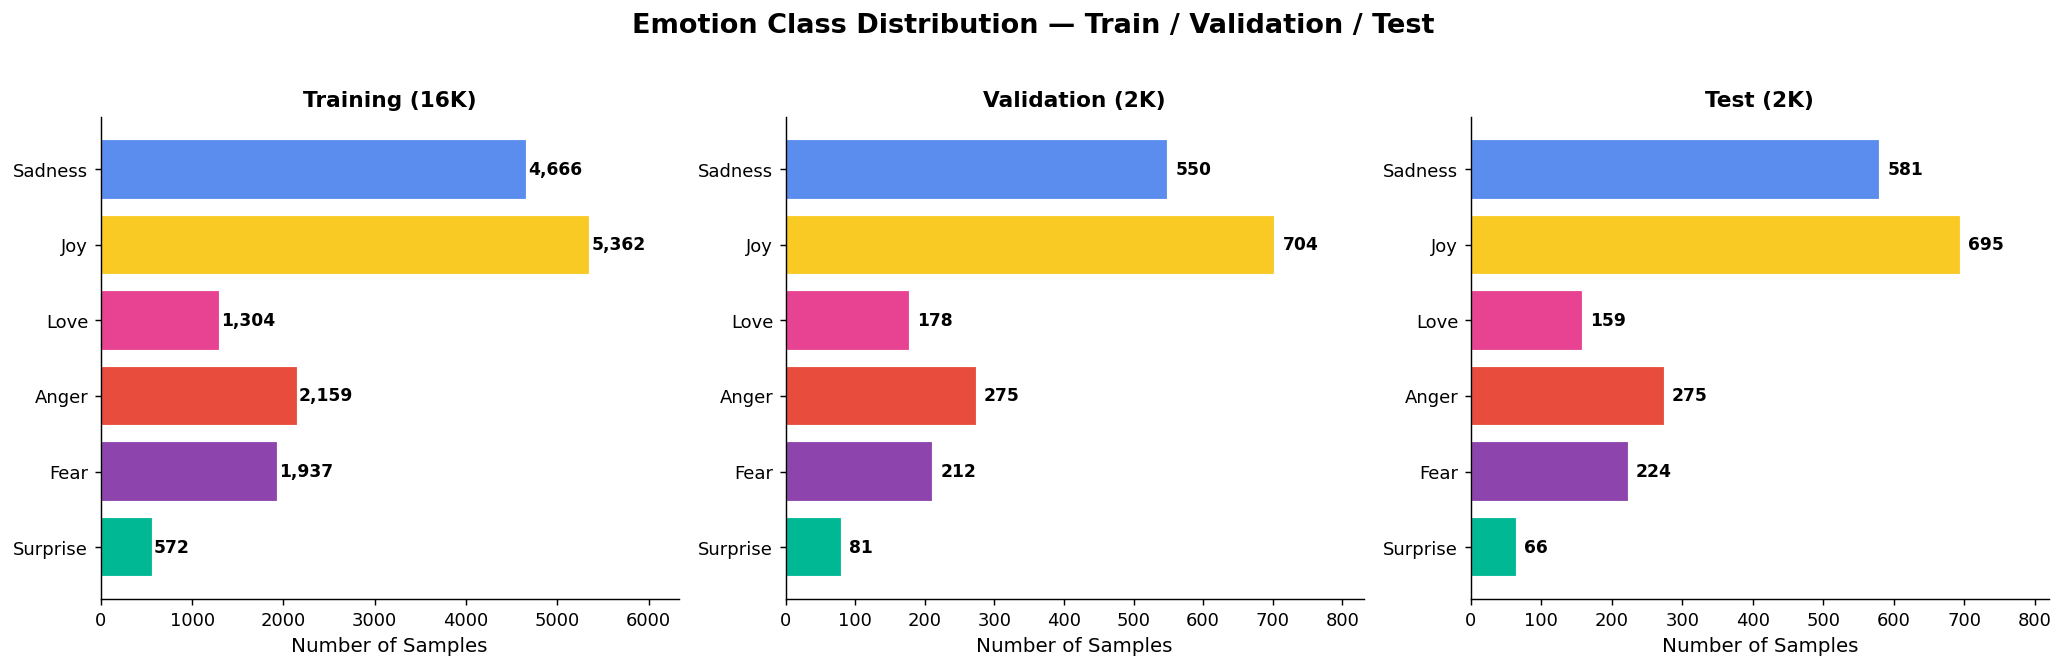

💾  Saved: viz_01_class_distribution.png


In [30]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   VIZ 01 — Class Distribution Across All Three Splits       ║
# ╚══════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Emotion Class Distribution — Train / Validation / Test',
             fontsize=15, fontweight='bold', y=1.02)

splits = [('Training (16K)', train_df), ('Validation (2K)', val_df), ('Test (2K)', test_df)]

for ax, (title, df) in zip(axes, splits):
    counts = [df[df['label']==i].shape[0] for i in range(6)]
    bars   = ax.barh(CLASS_NAMES[::-1], counts[::-1],
                     color=PALETTE[::-1], edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9.5, fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Number of Samples')
    ax.set_xlim(0, max(counts) * 1.18)

plt.tight_layout()
plt.savefig('viz_01_class_distribution.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_01_class_distribution.png')

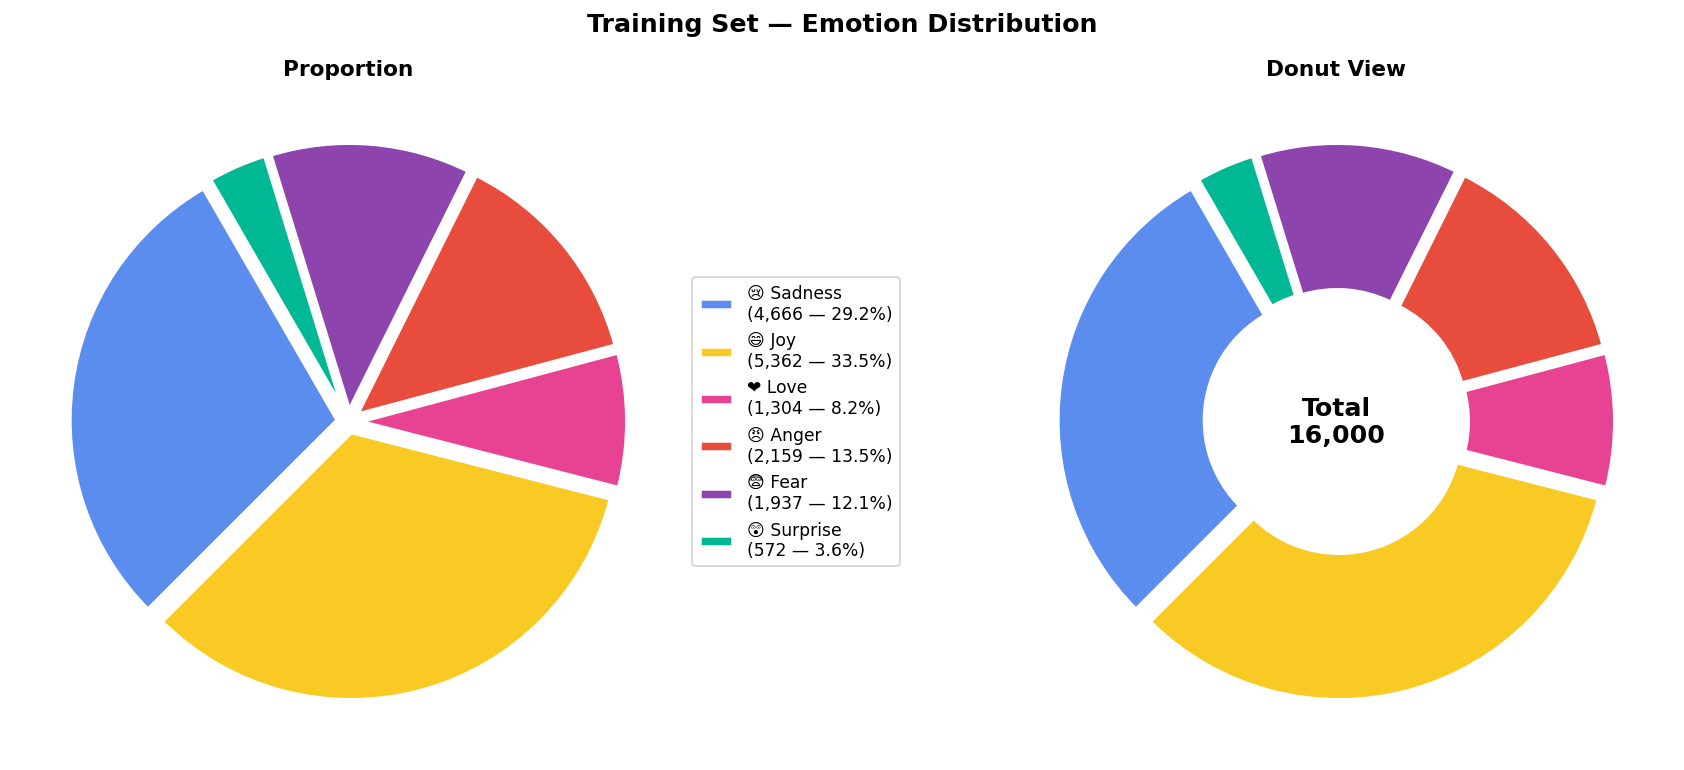

💾  Saved: viz_02_pie_donut.png


In [32]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   VIZ 02 — Training Set Pie Chart (Proportions)             ║
# ╚══════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Training Set — Emotion Distribution', fontsize=14, fontweight='bold')

counts = [train_df[train_df['label']==i].shape[0] for i in range(6)]
labels_pct = [f"{EMOTION_EMOJI[e]} {e}\n({c:,} — {c/sum(counts)*100:.1f}%)"
              for e, c in zip(CLASS_NAMES, counts)]

# Pie chart
wedges, texts = axes[0].pie(
    counts,
    labels     = None,
    colors     = PALETTE,
    startangle = 120,
    explode    = [0.04]*6,
    wedgeprops = {'edgecolor': 'white', 'linewidth': 2.5}
)
axes[0].legend(wedges, labels_pct, loc='center left',
               bbox_to_anchor=(1, 0.5), fontsize=9.5)
axes[0].set_title('Proportion', fontsize=12)

# Donut chart
axes[1].pie(counts, colors=PALETTE, startangle=120, explode=[0.04]*6,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2.5, 'width': 0.55})
axes[1].text(0, 0, f'Total\n{sum(counts):,}', ha='center', va='center',
             fontsize=14, fontweight='bold')
axes[1].set_title('Donut View', fontsize=12)

plt.tight_layout()
plt.savefig('viz_02_pie_donut.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_02_pie_donut.png')

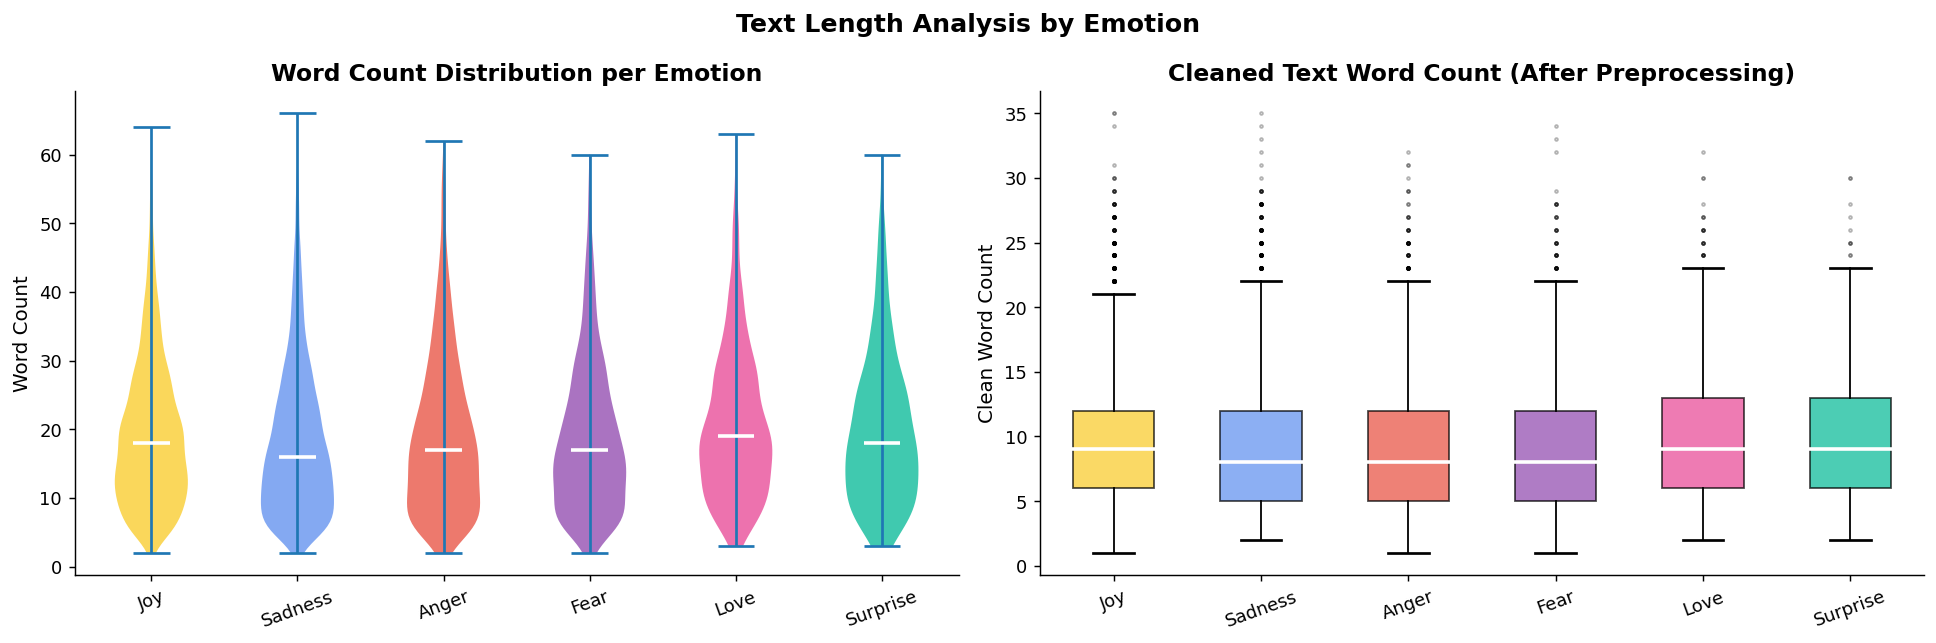

💾  Saved: viz_03_text_length.png


In [34]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   VIZ 03 — Text Length Distribution by Emotion              ║
# ╚══════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Text Length Analysis by Emotion', fontsize=14, fontweight='bold')

# Left: Violin plot of word count by emotion
emotion_order = ['Joy', 'Sadness', 'Anger', 'Fear', 'Love', 'Surprise']

emotion_data  = [train_df[train_df['emotion']==e]['word_count'].values for e in emotion_order]
bp = axes[0].violinplot(emotion_data, positions=range(len(emotion_order)),
                        showmedians=True, showmeans=False)

for i, (pc, color) in enumerate(zip(bp['bodies'], [EMOTION_COLORS[e] for e in emotion_order])):
    pc.set_facecolor(color)
    pc.set_alpha(0.75)

bp['cmedians'].set_color('white')
bp['cmedians'].set_linewidth(2)

axes[0].set_xticks(range(len(emotion_order)))
axes[0].set_xticklabels(emotion_order, rotation=20, fontsize=10)
axes[0].set_ylabel('Word Count')
axes[0].set_title('Word Count Distribution per Emotion')

# Right: Box plot
for i, emo in enumerate(emotion_order):
    data = train_df[train_df['emotion']==emo]['clean_words'].values
    axes[1].boxplot(data, positions=[i], widths=0.55, patch_artist=True,
                    boxprops=dict(facecolor=EMOTION_COLORS[emo], alpha=0.7),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=1),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='.', markersize=3, alpha=0.3))

axes[1].set_xticks(range(len(emotion_order)))
axes[1].set_xticklabels(emotion_order, rotation=20, fontsize=10)
axes[1].set_ylabel('Clean Word Count')
axes[1].set_title('Cleaned Text Word Count (After Preprocessing)')

plt.tight_layout()
plt.savefig('viz_03_text_length.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_03_text_length.png')

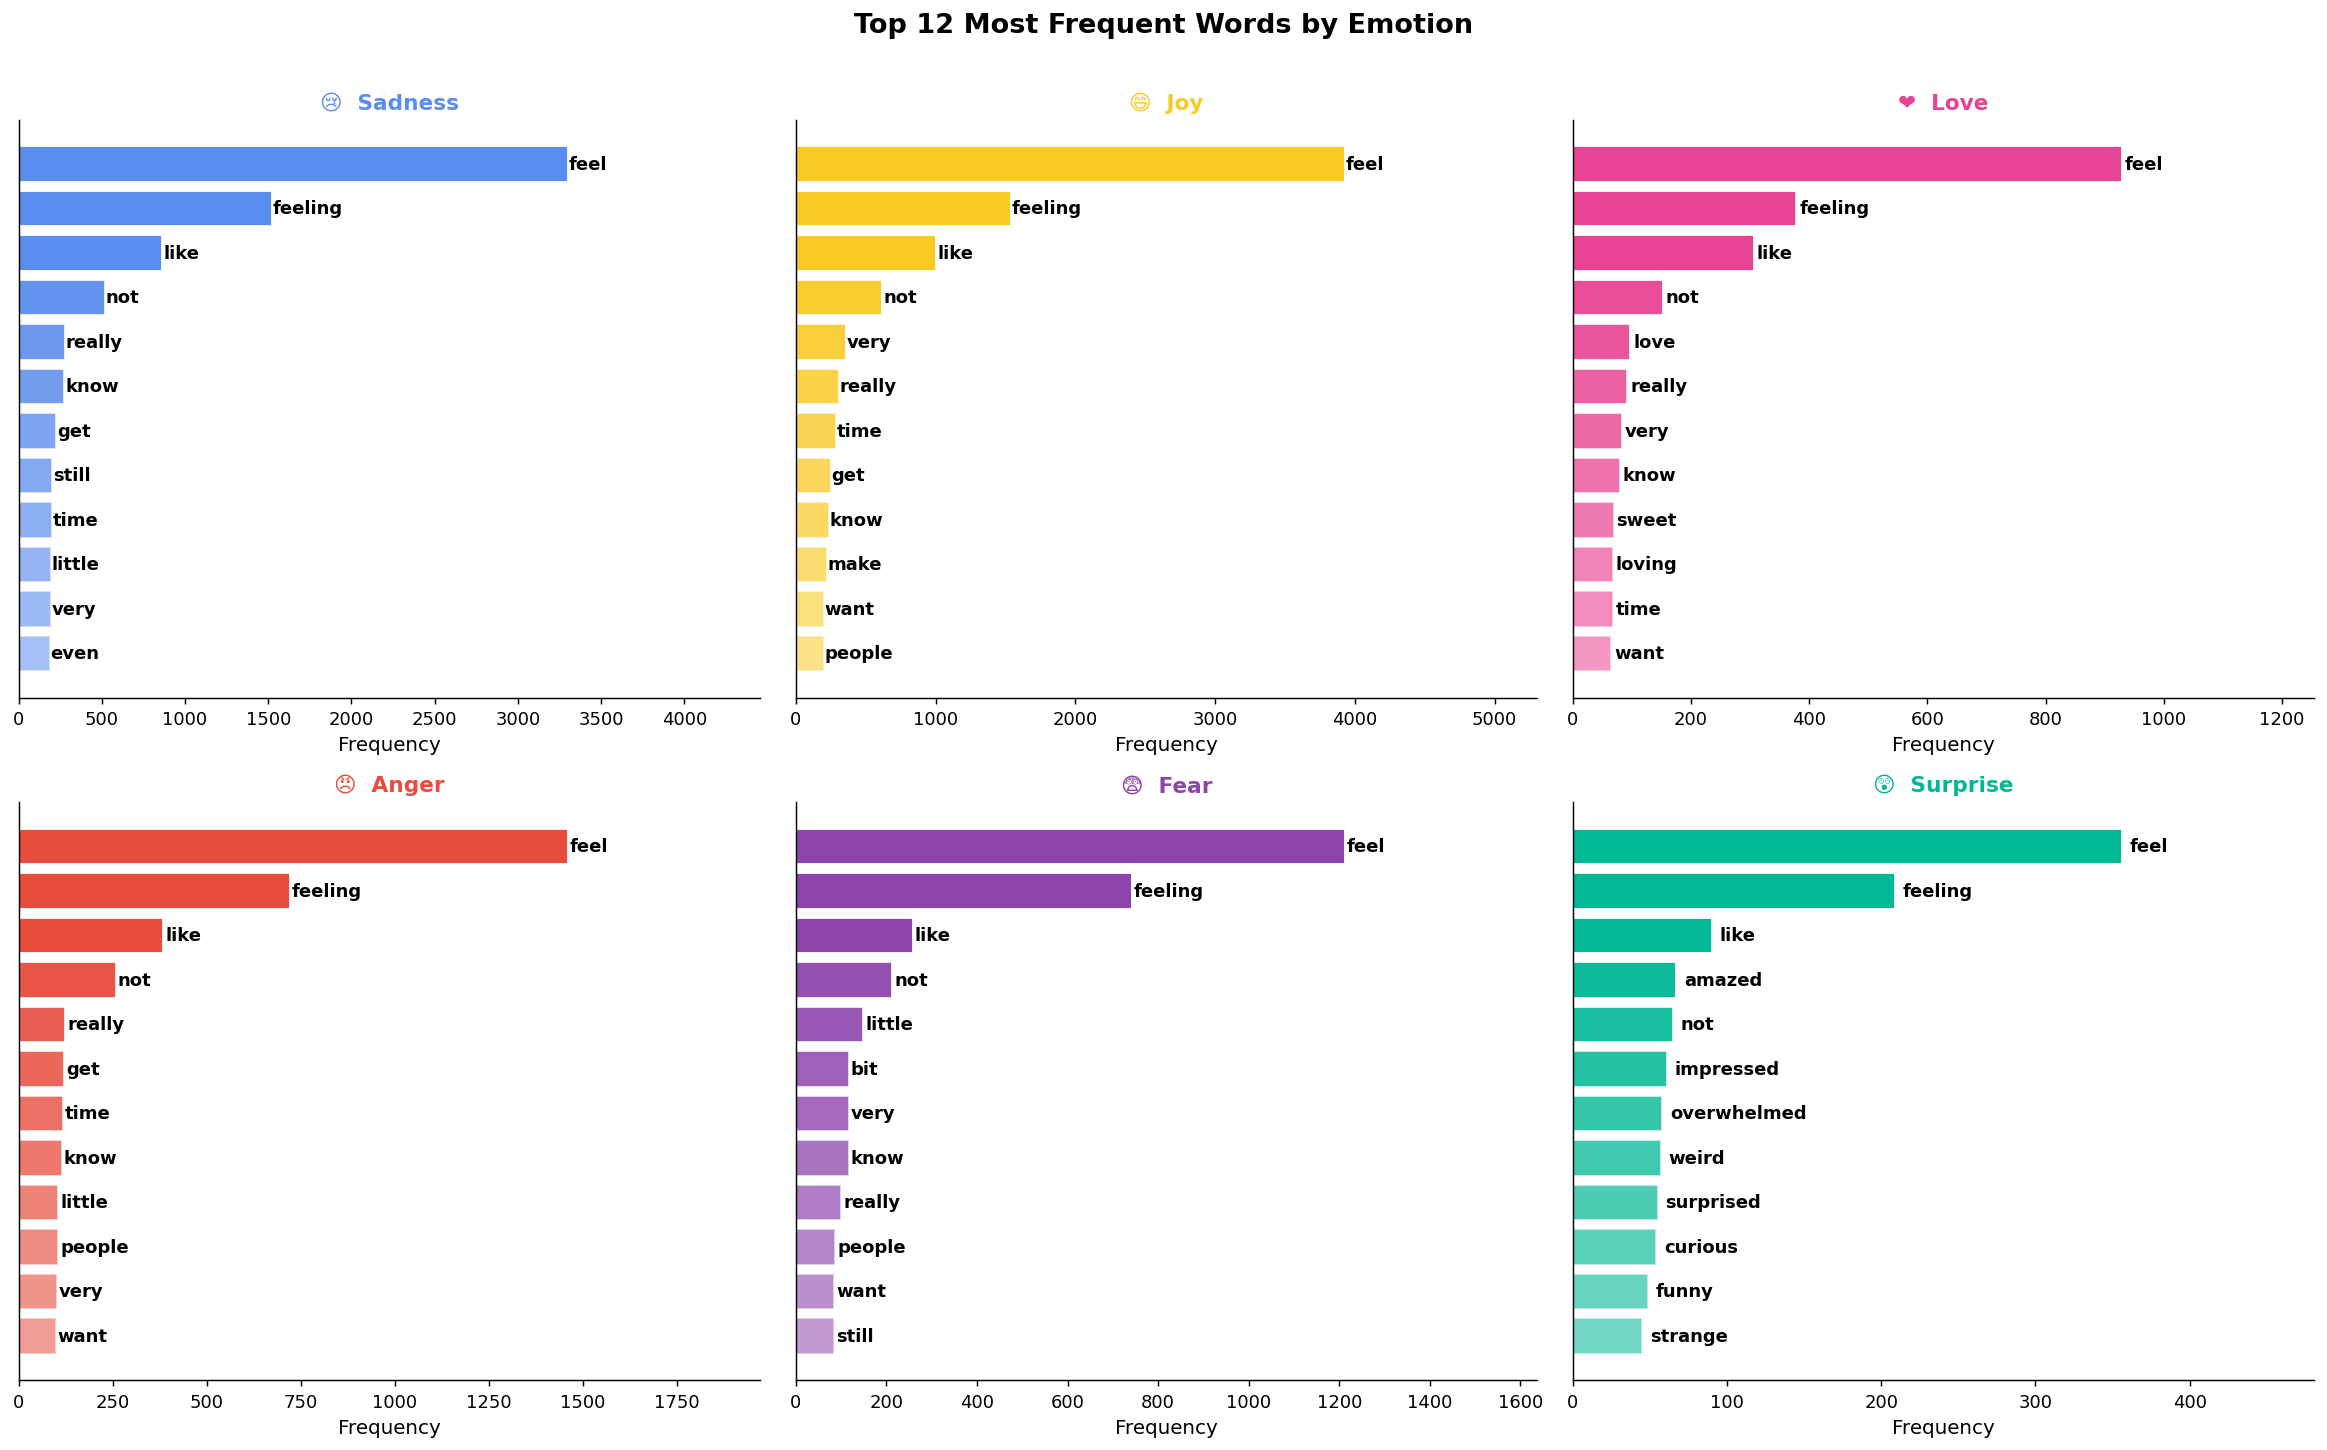

💾  Saved: viz_04_top_words.png


In [36]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   VIZ 04 — Top Words per Emotion Class                      ║
# ╚══════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Top 12 Most Frequent Words by Emotion', fontsize=15, fontweight='bold', y=1.01)

axes = axes.flatten()

for idx, (emo, color) in enumerate(EMOTION_COLORS.items()):
    # Get all cleaned text for this emotion
    corpus = ' '.join(train_df[train_df['emotion']==emo]['clean_text'])
    words  = corpus.split()
    
    # Count word frequencies
    top12  = Counter(words).most_common(12)
    w_list = [w for w, _ in top12]
    f_list = [f for _, f in top12]
    
    # Horizontal bar chart
    colors_grad = [color] * 12
    alphas = [0.9 - (i * 0.05) for i in range(12)]
    
    for j, (word, freq, alp) in enumerate(zip(w_list[::-1], f_list[::-1], alphas[::-1])):
        axes[idx].barh(j, freq, color=color, alpha=min(alp + 0.2, 1.0), edgecolor='white', height=0.8)
        axes[idx].text(freq + 5, j, word, va='center', fontsize=10, fontweight='bold')
    
    emoji = EMOTION_EMOJI[emo]
    axes[idx].set_title(f'{emoji}  {emo}', fontsize=12, fontweight='bold', color=color)
    axes[idx].set_yticks([])
    axes[idx].set_xlabel('Frequency')
    axes[idx].set_xlim(0, max(f_list) * 1.35)

plt.tight_layout()
plt.savefig('viz_04_top_words.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_04_top_words.png')

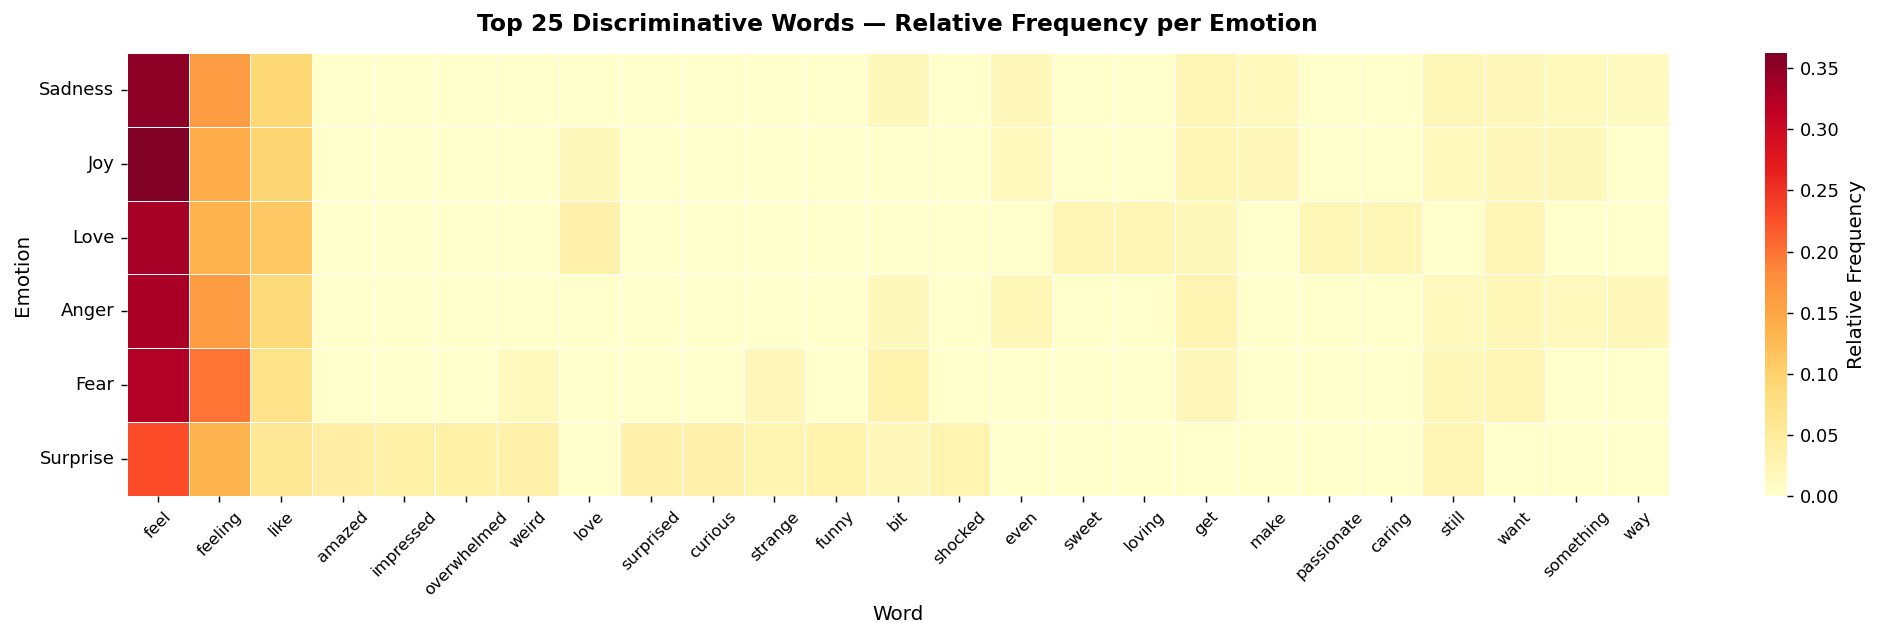

💾  Saved: viz_05_word_heatmap.png


In [38]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   VIZ 05 — Top Emotion-Differentiating Words Heatmap        ║
# ╚══════════════════════════════════════════════════════════════╝

# Build word frequency matrix across all emotions
top_words_per_emotion = {}
for emo in CLASS_NAMES:
    corpus = ' '.join(train_df[train_df['emotion']==emo]['clean_text'])
    top_words_per_emotion[emo] = dict(Counter(corpus.split()).most_common(30))

# Collect top discriminative words (high in one class, low in others)
all_top = set()
for emo_words in top_words_per_emotion.values():
    all_top.update(list(emo_words.keys())[:15])

all_top = sorted(all_top)

# Build matrix
matrix = pd.DataFrame(index=CLASS_NAMES, columns=all_top, dtype=float).fillna(0)
for emo, wdict in top_words_per_emotion.items():
    for word in all_top:
        matrix.loc[emo, word] = wdict.get(word, 0)

# Normalize row-wise so each emotion sums to 1
matrix_norm = matrix.div(matrix.sum(axis=1), axis=0)

# Filter to words with highest variance (most discriminative)
var_scores = matrix_norm.var(axis=0)
top_discrim = var_scores.nlargest(25).index.tolist()
matrix_plot = matrix_norm[top_discrim]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(matrix_plot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            linecolor='white', annot=False, cbar_kws={'label': 'Relative Frequency'})
ax.set_title('Top 25 Discriminative Words — Relative Frequency per Emotion',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Word')
ax.set_ylabel('Emotion')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('viz_05_word_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_05_word_heatmap.png')

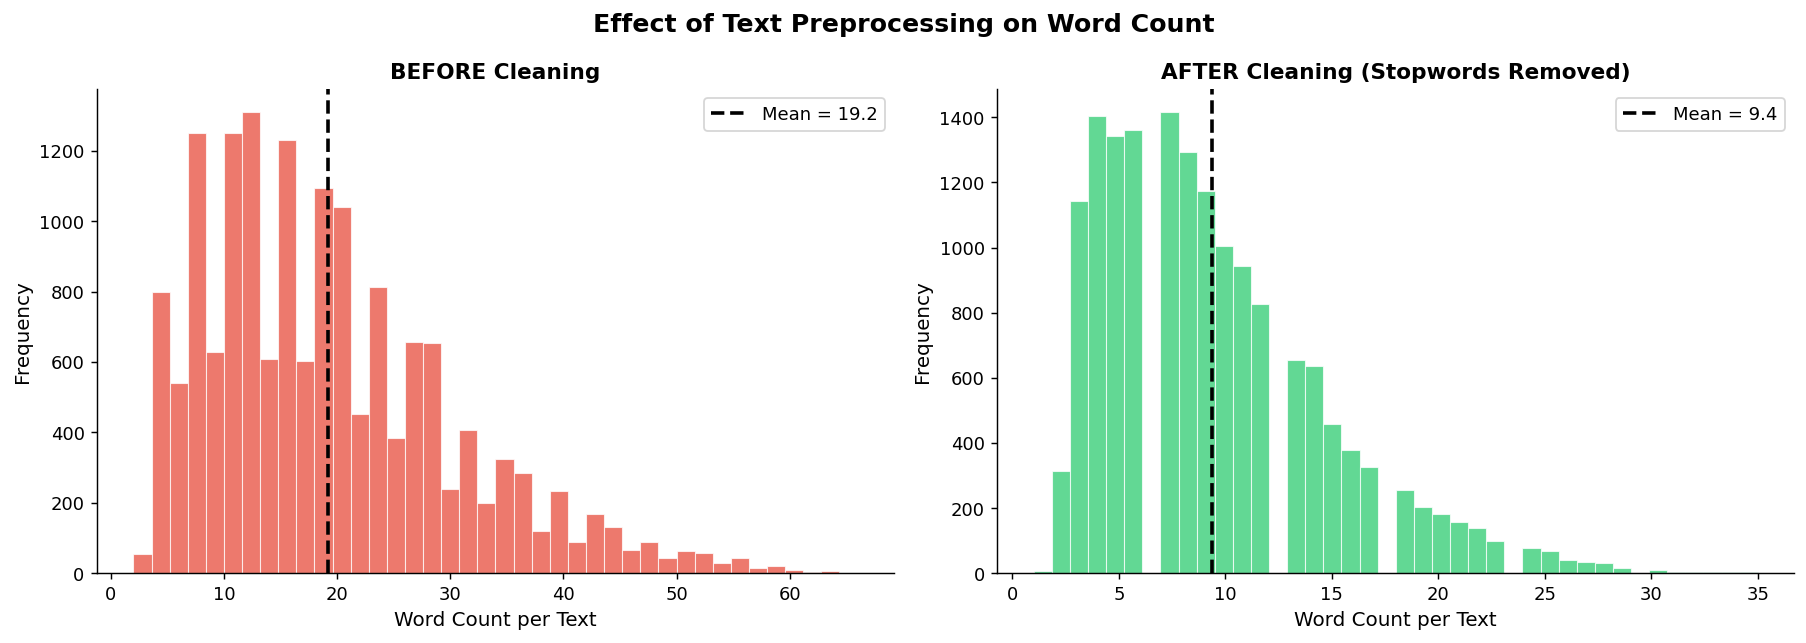

💾  Saved: viz_06_before_after_cleaning.png


In [40]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   VIZ 06 — Before vs After Cleaning (Text Length Change)    ║
# ╚══════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of Text Preprocessing on Word Count', fontsize=14, fontweight='bold')

# Before cleaning
axes[0].hist(train_df['word_count'], bins=40, color='#e74c3c', alpha=0.75,
             edgecolor='white', linewidth=0.6)
axes[0].axvline(train_df['word_count'].mean(), color='black',
                linestyle='--', linewidth=2, label=f'Mean = {train_df["word_count"].mean():.1f}')
axes[0].set_title('BEFORE Cleaning', fontsize=12)
axes[0].set_xlabel('Word Count per Text')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# After cleaning
axes[1].hist(train_df['clean_words'], bins=40, color='#2ecc71', alpha=0.75,
             edgecolor='white', linewidth=0.6)
axes[1].axvline(train_df['clean_words'].mean(), color='black',
                linestyle='--', linewidth=2, label=f'Mean = {train_df["clean_words"].mean():.1f}')
axes[1].set_title('AFTER Cleaning (Stopwords Removed)', fontsize=12)
axes[1].set_xlabel('Word Count per Text')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('viz_06_before_after_cleaning.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_06_before_after_cleaning.png')

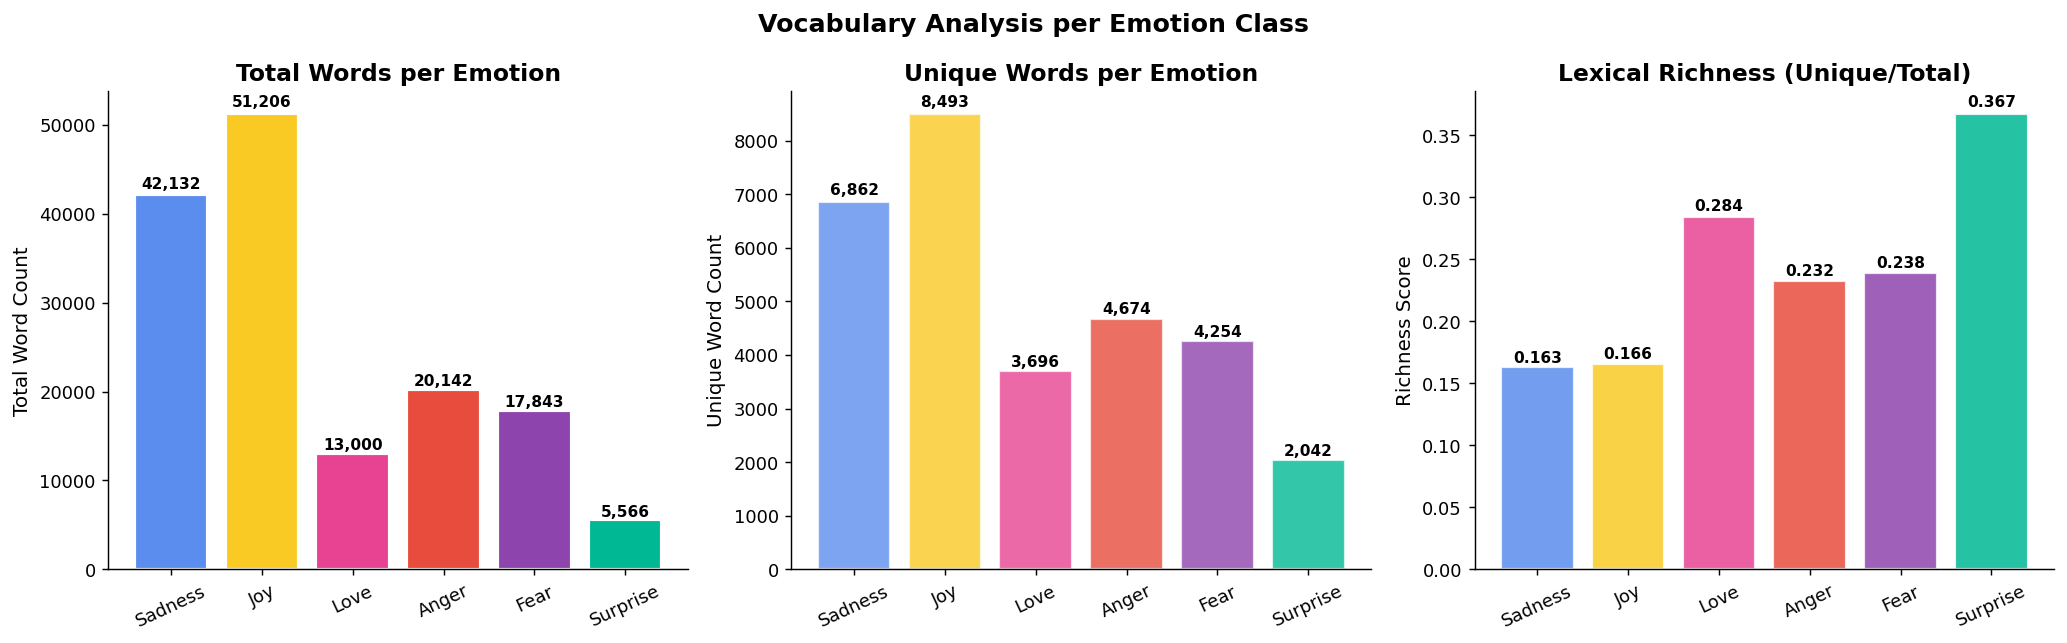

💾  Saved: viz_07_vocabulary.png


In [42]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   VIZ 07 — Vocabulary Size & Unique Words per Emotion       ║
# ╚══════════════════════════════════════════════════════════════╝

vocab_stats = {}
for emo in CLASS_NAMES:
    corpus     = ' '.join(train_df[train_df['emotion']==emo]['clean_text'])
    words      = corpus.split()
    vocab_stats[emo] = {
        'total_words'  : len(words),
        'unique_words' : len(set(words)),
        'richness'     : len(set(words)) / len(words) if words else 0
    }

vocab_df = pd.DataFrame(vocab_stats).T

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Vocabulary Analysis per Emotion Class', fontsize=14, fontweight='bold')

emotions   = list(vocab_df.index)
em_colors  = [EMOTION_COLORS[e] for e in emotions]

# Total words
axes[0].bar(emotions, vocab_df['total_words'], color=em_colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Total Words per Emotion')
axes[0].set_ylabel('Total Word Count')
axes[0].tick_params(axis='x', rotation=25)

# Unique words
axes[1].bar(emotions, vocab_df['unique_words'], color=em_colors, edgecolor='white', linewidth=1.2, alpha=0.8)
axes[1].set_title('Unique Words per Emotion')
axes[1].set_ylabel('Unique Word Count')
axes[1].tick_params(axis='x', rotation=25)

# Lexical richness (unique/total)
axes[2].bar(emotions, vocab_df['richness'], color=em_colors, edgecolor='white', linewidth=1.2, alpha=0.85)
axes[2].set_title('Lexical Richness (Unique/Total)')
axes[2].set_ylabel('Richness Score')
axes[2].tick_params(axis='x', rotation=25)
for ax in axes:
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{bar.get_height():,.0f}' if bar.get_height() > 1 else f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_07_vocabulary.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_07_vocabulary.png')

---
## 🔢 STEP 06 — Feature Extraction: Bag-of-Words & TF-IDF
> Convert cleaned text into numerical matrices that ML models can learn from.

In [45]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 06A — PREPARE X AND y FOR ALL SPLITS           ║
# ╚══════════════════════════════════════════════════════════════╝

# Features (X) = cleaned text string
# Target  (y)  = label (0-5)

X_train = train_df['clean_text'].values    # 16,000 texts for training
y_train = train_df['label'].values         # 16,000 labels

X_val   = val_df['clean_text'].values      # 2,000 texts for validation
y_val   = val_df['label'].values           # 2,000 labels

X_test  = test_df['clean_text'].values     # 2,000 texts for final test
y_test  = test_df['label'].values          # 2,000 labels

print('✅  Data prepared for vectorization')
print(f'   X_train shape : {X_train.shape}  —  y_train shape : {y_train.shape}')
print(f'   X_val   shape : {X_val.shape}  —  y_val   shape : {y_val.shape}')
print(f'   X_test  shape : {X_test.shape}  —  y_test  shape : {y_test.shape}')

✅  Data prepared for vectorization
   X_train shape : (16000,)  —  y_train shape : (16000,)
   X_val   shape : (2000,)  —  y_val   shape : (2000,)
   X_test  shape : (2000,)  —  y_test  shape : (2000,)


In [47]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 06B — BAG-OF-WORDS (BoW) VECTORIZATION         ║
# ╚══════════════════════════════════════════════════════════════╝
#
# CountVectorizer builds a vocabulary from training data,
# then counts how many times each word appears per document.
# Result: sparse matrix [n_samples × vocab_size]

bow_vectorizer = CountVectorizer(
    max_features = 10000,     # Keep top 10,000 words by frequency
    ngram_range  = (1, 2),    # Use unigrams AND bigrams (e.g. 'very happy')
    min_df       = 2,         # Ignore words appearing in < 2 documents
    max_df       = 0.95,      # Ignore words appearing in > 95% of docs
    analyzer     = 'word',    # Word-level tokenization
    strip_accents= 'unicode'  # Normalize accented characters
)

# ⚠️  CRITICAL: Fit ONLY on training data (prevents data leakage)
X_train_bow = bow_vectorizer.fit_transform(X_train)   # Fit + transform train
X_val_bow   = bow_vectorizer.transform(X_val)          # Only transform val
X_test_bow  = bow_vectorizer.transform(X_test)         # Only transform test

vocab_size  = len(bow_vectorizer.vocabulary_)

print('✅  Bag-of-Words Vectorization Complete')
print(f'   Vocabulary size   : {vocab_size:,}')
print(f'   Train matrix      : {X_train_bow.shape}  → {X_train_bow.nnz:,} non-zero')
print(f'   Val   matrix      : {X_val_bow.shape}')
print(f'   Test  matrix      : {X_test_bow.shape}')
density = X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1])
print(f'   Matrix density    : {density*100:.3f}% (very sparse — normal for NLP)')
print(f'\n   Sample tokens (first 20): {list(bow_vectorizer.get_feature_names_out()[:20])}')

✅  Bag-of-Words Vectorization Complete
   Vocabulary size   : 10,000
   Train matrix      : (16000, 10000)  → 170,034 non-zero
   Val   matrix      : (2000, 10000)
   Test  matrix      : (2000, 10000)
   Matrix density    : 0.106% (very sparse — normal for NLP)

   Sample tokens (first 20): ['aa', 'abandon', 'abandoned', 'abandonment', 'abc', 'abdomen', 'abide', 'abilities', 'ability', 'abit', 'able', 'able come', 'able express', 'able feel', 'able find', 'able get', 'able go', 'able help', 'able keep', 'able let']


In [49]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 06C — TF-IDF VECTORIZATION (Recommended)       ║
# ╚══════════════════════════════════════════════════════════════╝
#
# TF-IDF = Term Frequency × Inverse Document Frequency
#   TF  : How often a word appears in THIS document
#   IDF : How rare the word is ACROSS all documents
#
# Words common everywhere (e.g. 'feel') get down-weighted.
# Words rare but specific (e.g. 'terrified') get up-weighted.

tfidf_vectorizer = TfidfVectorizer(
    max_features = 10000,      # Keep top 10,000 features
    ngram_range  = (1, 2),     # Unigrams + Bigrams
    min_df       = 2,          # Ignore very rare words
    max_df       = 0.95,       # Ignore words in almost every document
    sublinear_tf = True,       # Apply log(1+tf) → dampens very frequent words
    strip_accents= 'unicode',
    smooth_idf   = True,       # Prevent division by zero
    norm         = 'l2'        # L2 normalize each row (unit vector)
)

# Fit on train ONLY
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print('✅  TF-IDF Vectorization Complete')
print(f'   Vocabulary size   : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'   Train matrix      : {X_train_tfidf.shape}')
print(f'   Val   matrix      : {X_val_tfidf.shape}')
print(f'   Test  matrix      : {X_test_tfidf.shape}')

# Show top TF-IDF scoring tokens
feat_names  = tfidf_vectorizer.get_feature_names_out()
mean_tfidf  = X_train_tfidf.mean(axis=0).A1
top_idx     = mean_tfidf.argsort()[::-1][:15]
print(f'\n   Top 15 TF-IDF tokens: {[feat_names[i] for i in top_idx]}')

✅  TF-IDF Vectorization Complete
   Vocabulary size   : 10,000
   Train matrix      : (16000, 10000)
   Val   matrix      : (2000, 10000)
   Test  matrix      : (2000, 10000)

   Top 15 TF-IDF tokens: ['feel', 'feeling', 'like', 'feel like', 'not', 'very', 'really', 'know', 'little', 'time', 'get', 'still', 'want', 'people', 'bit']


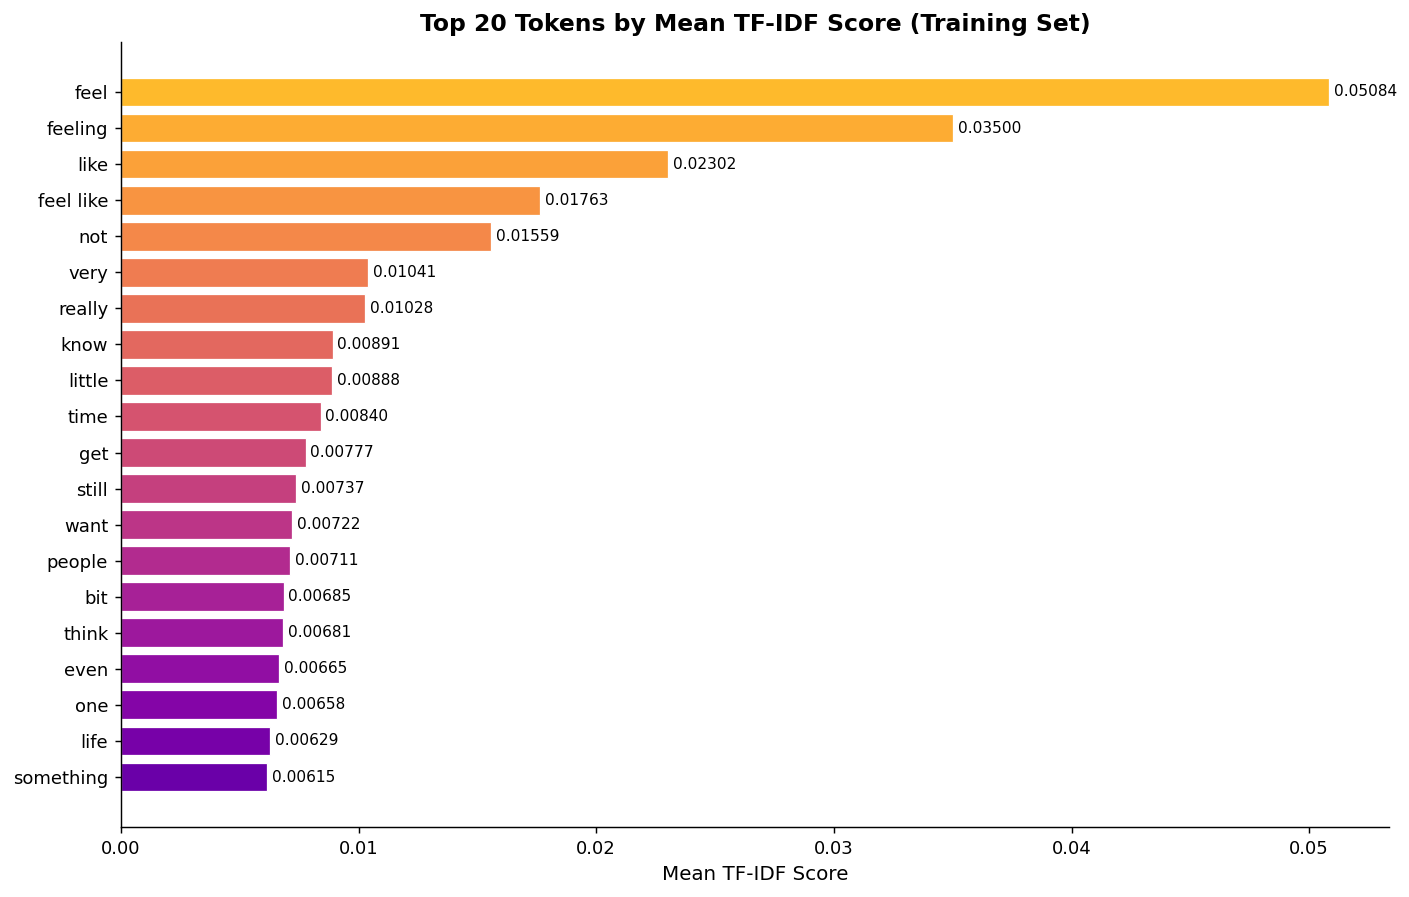

💾  Saved: viz_08_tfidf_top.png


In [51]:
# ── Visualize TF-IDF top features ─────────────────────────────
top_n     = 20
top_idx_v = mean_tfidf.argsort()[::-1][:top_n]
top_words = [feat_names[i] for i in top_idx_v]
top_vals  = [mean_tfidf[i] for i in top_idx_v]

colors_g  = plt.cm.plasma(np.linspace(0.2, 0.85, top_n))

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_words[::-1], top_vals[::-1], color=colors_g, edgecolor='white', linewidth=0.7)

for bar, val in zip(bars, top_vals[::-1]):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.5f}', va='center', fontsize=8.5)

ax.set_title(f'Top {top_n} Tokens by Mean TF-IDF Score (Training Set)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean TF-IDF Score')

plt.tight_layout()
plt.savefig('viz_08_tfidf_top.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_08_tfidf_top.png')

---
## 🤖 STEP 07 — Model Building & Training (5 Models)
> Train all models on TF-IDF features and evaluate on Validation set.

In [54]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 07A — DEFINE ALL MODELS                        ║
# ╚══════════════════════════════════════════════════════════════╝

models = {

    # ── Model 1: Multinomial Naive Bayes ──────────────────────
    # Classic NLP baseline. Fast, interpretable, works well with
    # count/TF-IDF features. Good for sparse high-dimensional text.
    'Naive Bayes': MultinomialNB(
        alpha=0.1            # Laplace smoothing — prevents zero probabilities
    ),

    # ── Model 2: Logistic Regression ──────────────────────────
    # Strong linear classifier. Outputs calibrated probabilities.
    # Excellent for NLP when features are TF-IDF vectors.
    'Logistic Regression': LogisticRegression(
        C           = 5.0,   # Inverse regularization strength (higher = less regularization)
        max_iter    = 1000,  # Increase for convergence on text data
        solver      = 'lbfgs',
        multi_class = 'multinomial',  # True multiclass
        random_state= 42
    ),

    # ── Model 3: Linear SVM ───────────────────────────────────
    # Industry standard for text classification.
    # Finds maximum-margin hyperplane between classes.
    'Linear SVM': LinearSVC(
        C           = 1.0,   # Regularization
        max_iter    = 3000,  # Sufficient for convergence
        random_state= 42
    ),

    # ── Model 4: Random Forest ────────────────────────────────
    # Ensemble of decision trees. Robust, handles noisy data well.
    # Slower than linear models on sparse NLP features.
    'Random Forest': RandomForestClassifier(
        n_estimators= 200,   # Number of trees
        max_depth   = 30,    # Limit depth to prevent overfitting
        random_state= 42,
        n_jobs      = -1     # Use all CPU cores
    ),

    # ── Model 5: Gradient Boosting ────────────────────────────
    # Sequential ensemble — each tree corrects previous errors.
    # Strong but slower to train.
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators   = 150,
        learning_rate  = 0.1,
        max_depth      = 5,
        random_state   = 42
    )
}

print('🤖  Models ready for training:')
for name in models:
    print(f'   ✓  {name}')

🤖  Models ready for training:
   ✓  Naive Bayes
   ✓  Logistic Regression
   ✓  Linear SVM
   ✓  Random Forest
   ✓  Gradient Boosting


In [56]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 07B — TRAIN & VALIDATE ALL MODELS              ║
# ╚══════════════════════════════════════════════════════════════╝

results      = {}   # Store results for comparison
model_names  = list(models.keys())

print('=' * 65)
print('  TRAINING PHASE — TF-IDF Features  |  Eval on Validation Set')
print('=' * 65)

for name, model in models.items():
    print(f'\n  ⏳  Training: {name}...')

    # ── TRAIN on training data ─────────────────────────────────
    model.fit(X_train_tfidf, y_train)

    # ── PREDICT on validation data ────────────────────────────
    y_pred_val = model.predict(X_val_tfidf)

    # ── METRICS ───────────────────────────────────────────────
    val_acc      = accuracy_score(y_val, y_pred_val)
    val_f1_w     = f1_score(y_val, y_pred_val, average='weighted')   # Weighted (handles imbalance)
    val_f1_mac   = f1_score(y_val, y_pred_val, average='macro')      # Macro (penalizes minority class)
    val_prec     = precision_score(y_val, y_pred_val, average='weighted', zero_division=0)
    val_rec      = recall_score(y_val, y_pred_val, average='weighted')

    results[name] = {
        'model'       : model,
        'y_pred_val'  : y_pred_val,
        'val_acc'     : val_acc,
        'val_f1_w'    : val_f1_w,
        'val_f1_mac'  : val_f1_mac,
        'val_prec'    : val_prec,
        'val_rec'     : val_rec,
    }

    print(f'     Val Accuracy : {val_acc*100:.2f}%')
    print(f'     F1 Weighted  : {val_f1_w:.4f}')
    print(f'     F1 Macro     : {val_f1_mac:.4f}')

print('\n' + '=' * 65)
print('✅  All 5 models trained and evaluated on validation set!')

  TRAINING PHASE — TF-IDF Features  |  Eval on Validation Set

  ⏳  Training: Naive Bayes...
     Val Accuracy : 83.10%
     F1 Weighted  : 0.8232
     F1 Macro     : 0.7628

  ⏳  Training: Logistic Regression...
     Val Accuracy : 90.35%
     F1 Weighted  : 0.9024
     F1 Macro     : 0.8693

  ⏳  Training: Linear SVM...
     Val Accuracy : 90.85%
     F1 Weighted  : 0.9080
     F1 Macro     : 0.8769

  ⏳  Training: Random Forest...
     Val Accuracy : 60.20%
     F1 Weighted  : 0.5655
     F1 Macro     : 0.4742

  ⏳  Training: Gradient Boosting...
     Val Accuracy : 89.05%
     F1 Weighted  : 0.8907
     F1 Macro     : 0.8691

✅  All 5 models trained and evaluated on validation set!


---
## 📈 STEP 08 — Model Evaluation & Visual Comparison

In [59]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 08A — DETAILED CLASSIFICATION REPORTS          ║
# ╚══════════════════════════════════════════════════════════════╝

for name, res in results.items():
    print('\n' + '═' * 58)
    print(f'  📊  {name}  (Validation Set)')
    print('═' * 58)
    print(classification_report(
        y_val, res['y_pred_val'],
        target_names = CLASS_NAMES,
        digits       = 4
    ))


══════════════════════════════════════════════════════════
  📊  Naive Bayes  (Validation Set)
══════════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Sadness     0.8167    0.9236    0.8669       550
         Joy     0.8213    0.9403    0.8768       704
        Love     0.8667    0.5112    0.6431       178
       Anger     0.8833    0.7709    0.8233       275
        Fear     0.8343    0.7123    0.7684       212
    Surprise     0.8261    0.4691    0.5984        81

    accuracy                         0.8310      2000
   macro avg     0.8414    0.7213    0.7628      2000
weighted avg     0.8342    0.8310    0.8232      2000


══════════════════════════════════════════════════════════
  📊  Logistic Regression  (Validation Set)
══════════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Sadness     0.9236    0.9455    0.9344       550
         Joy     0.9060    0.944

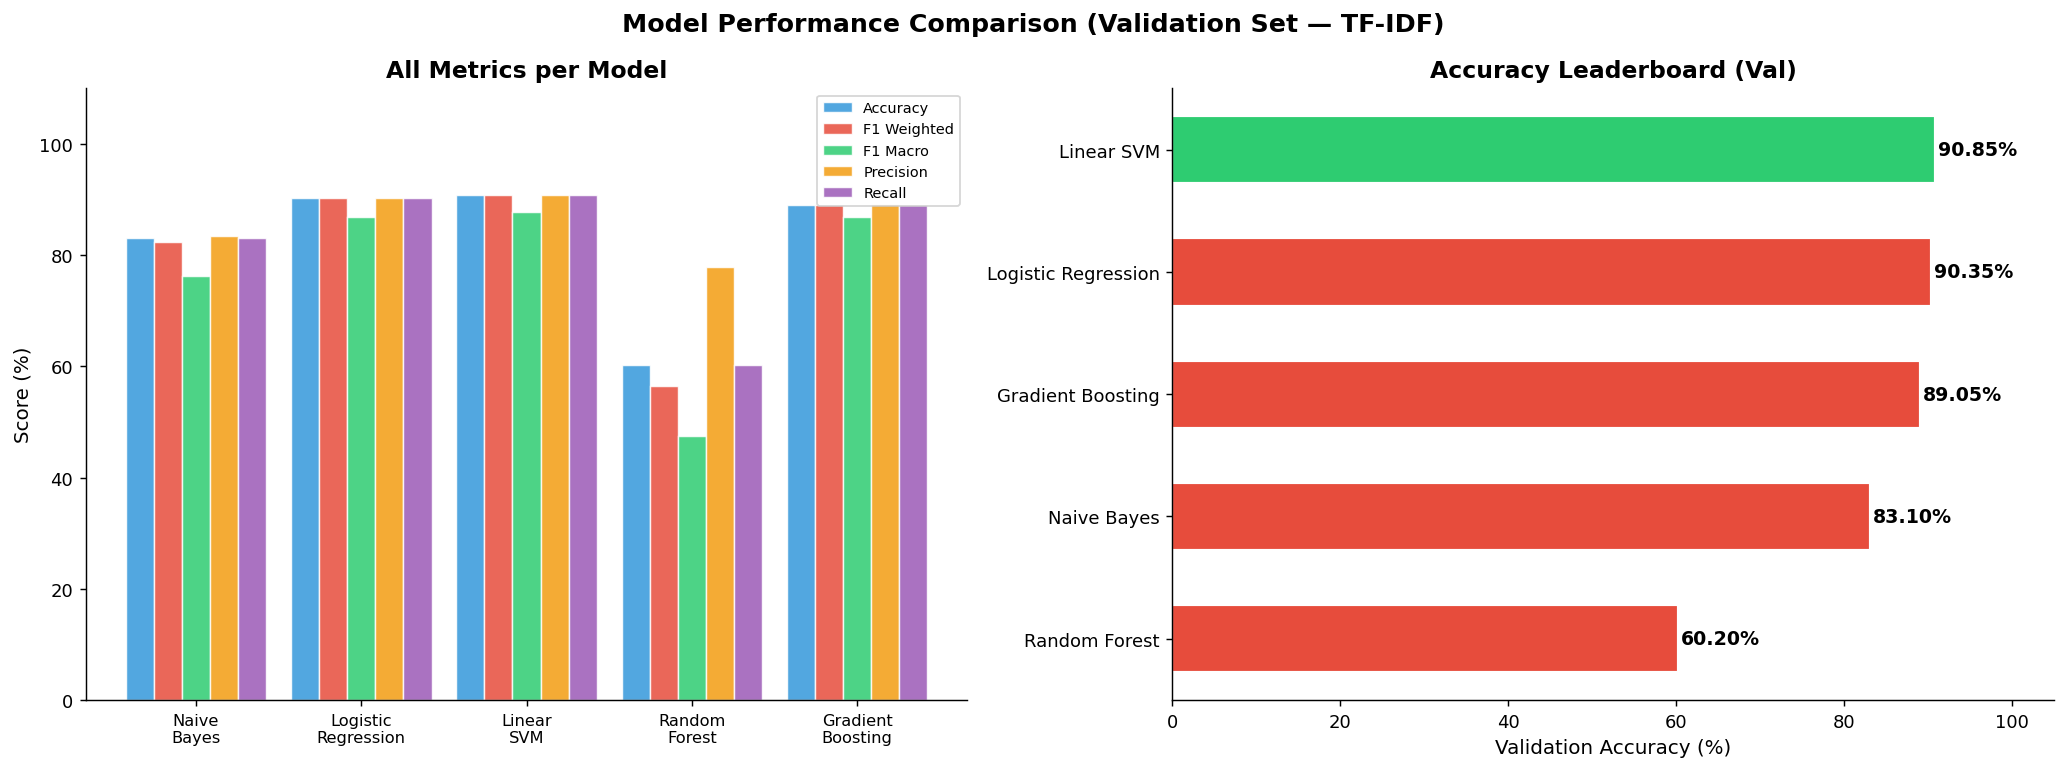

💾  Saved: viz_09_model_comparison.png


In [61]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 08B — MODEL COMPARISON BAR CHART               ║
# ╚══════════════════════════════════════════════════════════════╝

metrics_to_plot = {
    'Accuracy'    : [results[m]['val_acc']   * 100 for m in model_names],
    'F1 Weighted' : [results[m]['val_f1_w']  * 100 for m in model_names],
    'F1 Macro'    : [results[m]['val_f1_mac']* 100 for m in model_names],
    'Precision'   : [results[m]['val_prec']  * 100 for m in model_names],
    'Recall'      : [results[m]['val_rec']   * 100 for m in model_names],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison (Validation Set — TF-IDF)',
             fontsize=14, fontweight='bold')

bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
short_names = [n.replace(' ', '\n') for n in model_names]

# Left: Grouped bar chart
x    = np.arange(len(model_names))
w    = 0.17
offsets = [-2*w, -w, 0, w, 2*w]
colors  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (metric, values) in enumerate(metrics_to_plot.items()):
    axes[0].bar(x + offsets[i], values, w, label=metric,
                color=colors[i], alpha=0.85, edgecolor='white', linewidth=0.8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, fontsize=9)
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_title('All Metrics per Model')

# Right: Accuracy leaderboard
sorted_names = sorted(model_names, key=lambda m: results[m]['val_acc'])
sorted_accs  = [results[m]['val_acc']*100 for m in sorted_names]

bar_clrs = ['#e74c3c' if n != sorted_names[-1] else '#2ecc71' for n in sorted_names]
bars = axes[1].barh(sorted_names, sorted_accs, color=bar_clrs,
                    edgecolor='white', linewidth=1.2, height=0.55)
for bar, val in zip(bars, sorted_accs):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=10.5, fontweight='bold')
axes[1].set_xlim(0, 105)
axes[1].set_title('Accuracy Leaderboard (Val)')
axes[1].set_xlabel('Validation Accuracy (%)')

plt.tight_layout()
plt.savefig('viz_09_model_comparison.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_09_model_comparison.png')

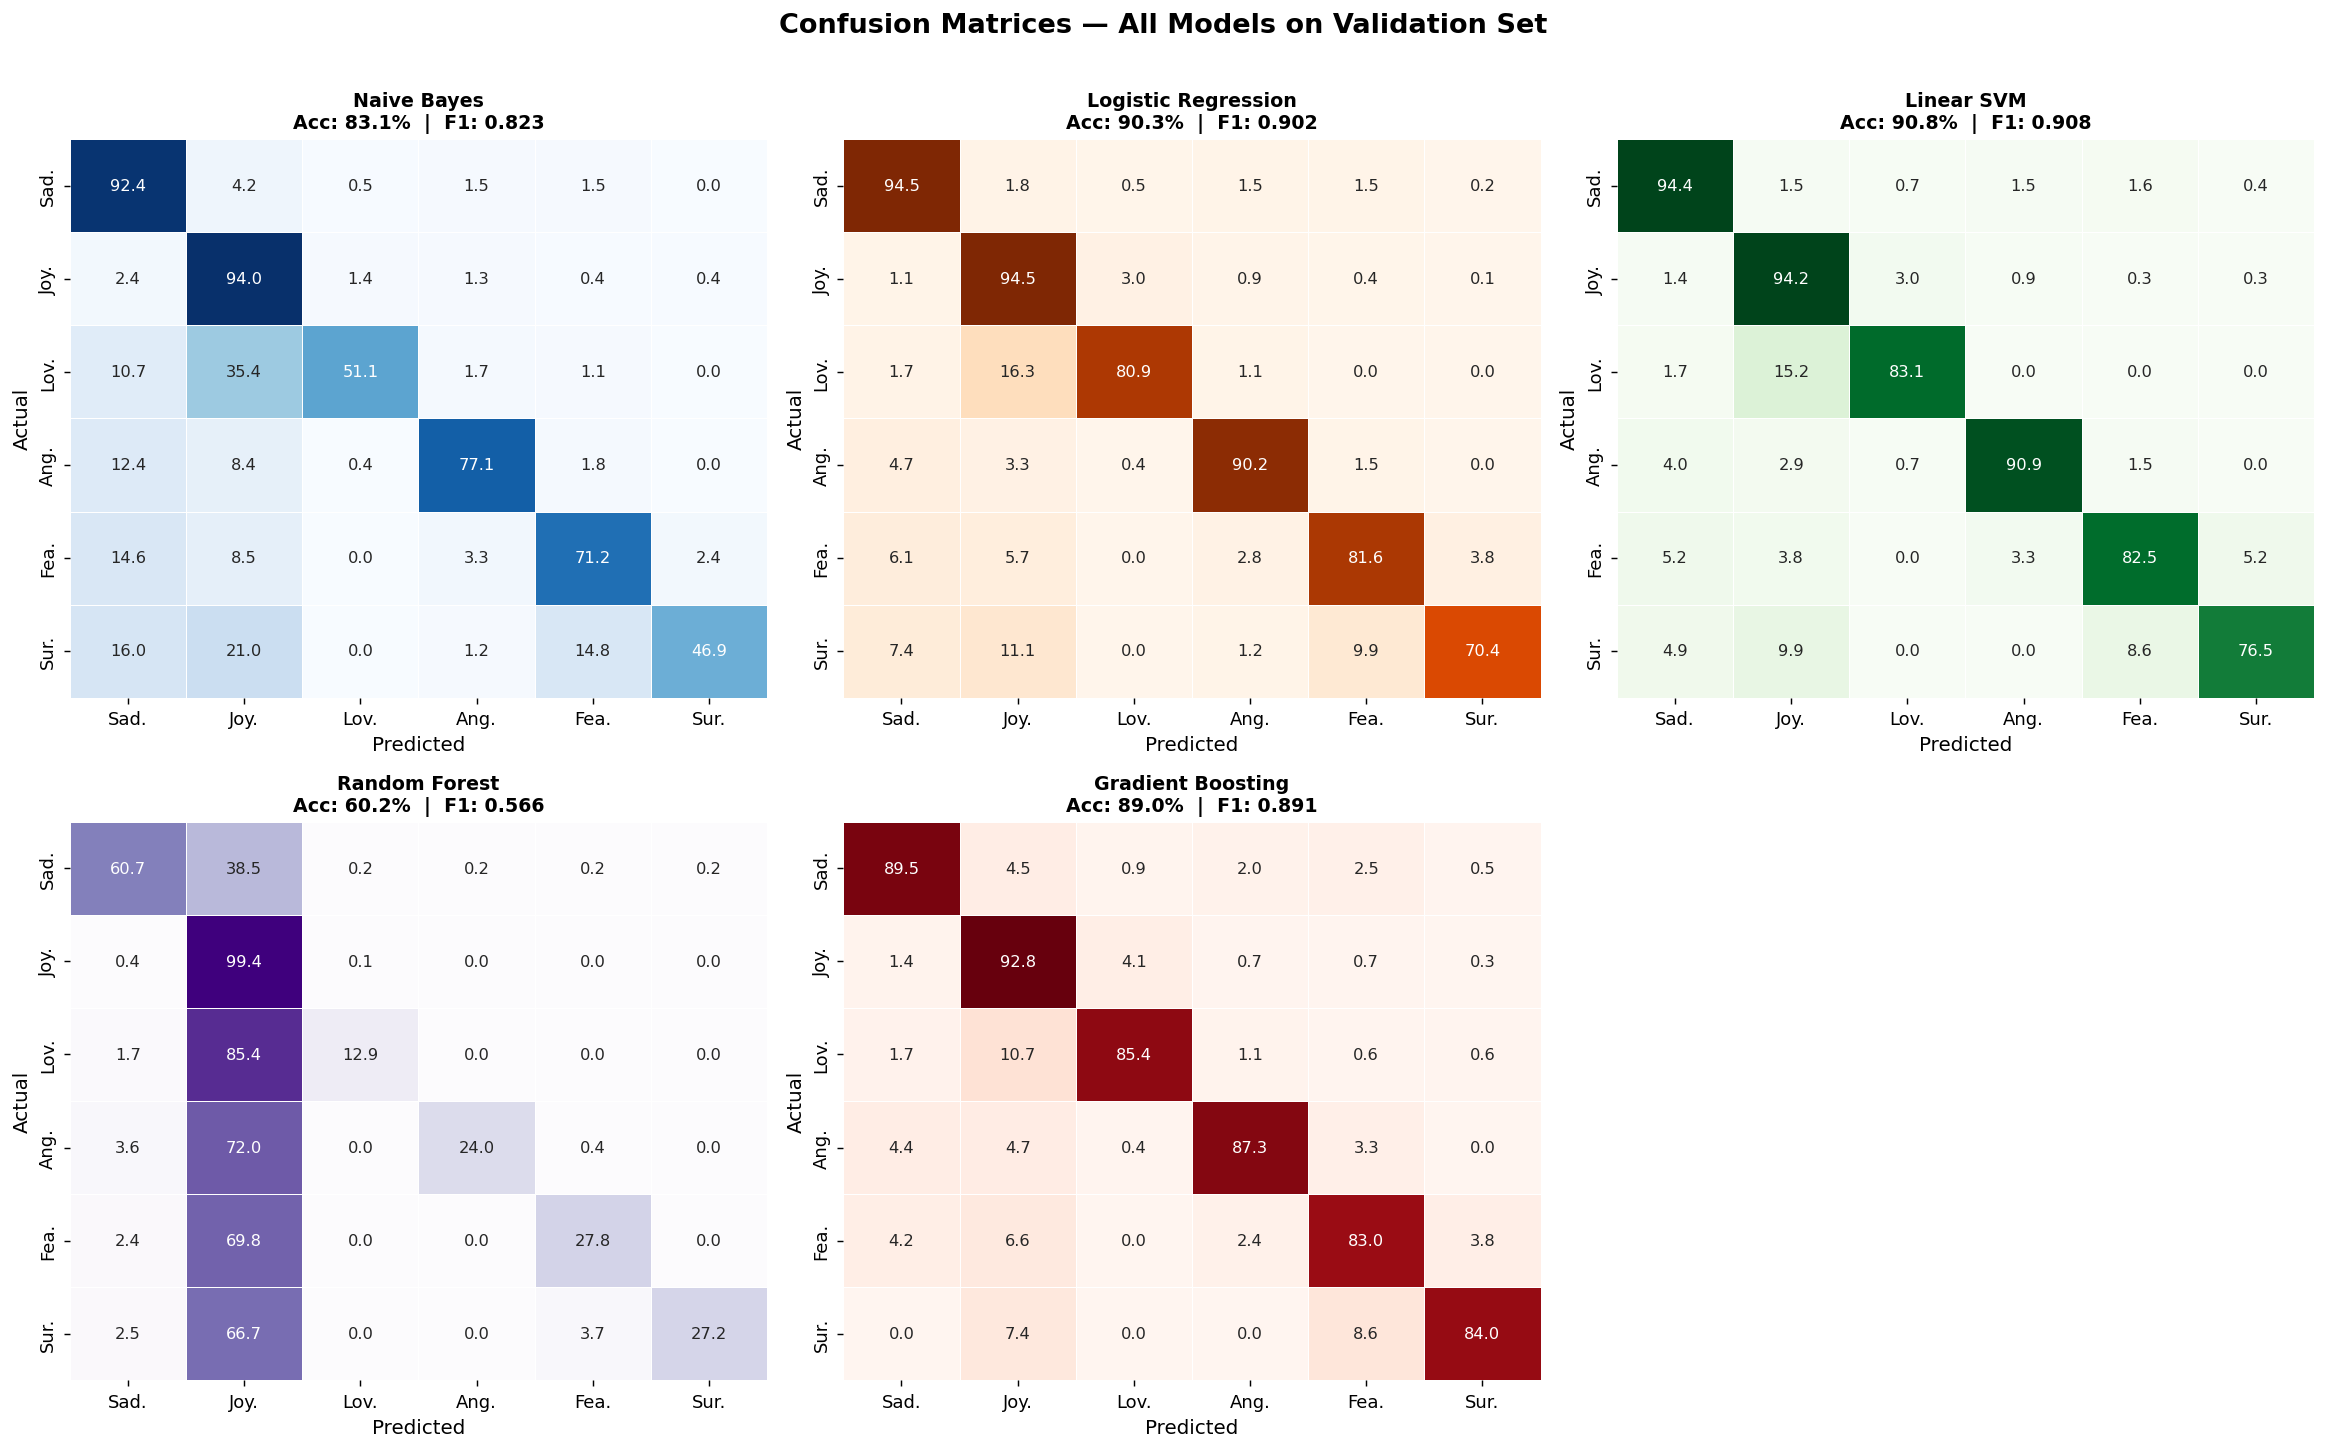

💾  Saved: viz_10_confusion_matrices.png


In [63]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 08C — CONFUSION MATRICES (ALL MODELS)          ║
# ╚══════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Confusion Matrices — All Models on Validation Set',
             fontsize=15, fontweight='bold', y=1.01)

axes_flat = axes.flatten()
cmaps = ['Blues', 'Oranges', 'Greens', 'Purples', 'Reds']

for idx, (name, res) in enumerate(results.items()):
    cm      = confusion_matrix(y_val, res['y_pred_val'])
    cm_pct  = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(
        cm_pct,
        annot         = True,
        fmt           = '.1f',
        cmap          = cmaps[idx],
        xticklabels   = [f'{e[:3]}.' for e in CLASS_NAMES],
        yticklabels   = [f'{e[:3]}.' for e in CLASS_NAMES],
        ax            = axes_flat[idx],
        linewidths    = 0.5,
        linecolor     = 'white',
        cbar          = False,
        annot_kws     = {'size': 9}
    )
    axes_flat[idx].set_title(
        f'{name}\nAcc: {res["val_acc"]*100:.1f}%  |  F1: {res["val_f1_w"]:.3f}',
        fontsize=10.5, fontweight='bold'
    )
    axes_flat[idx].set_xlabel('Predicted')
    axes_flat[idx].set_ylabel('Actual')

# Hide unused subplot (6th position)
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('viz_10_confusion_matrices.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_10_confusion_matrices.png')

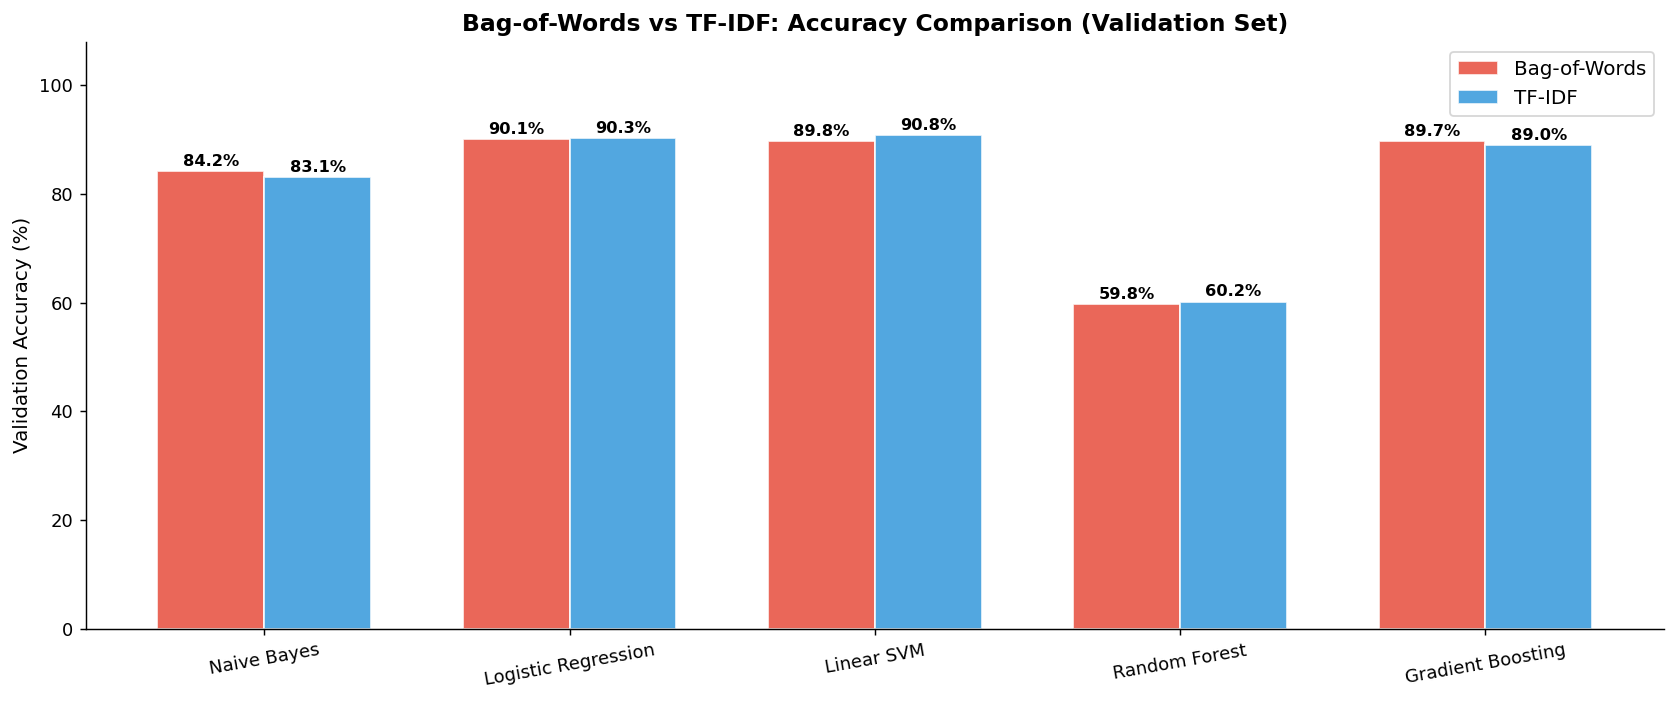

💾  Saved: viz_11_bow_vs_tfidf.png


In [65]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 08D — BOW vs TF-IDF COMPARISON                 ║
# ╚══════════════════════════════════════════════════════════════╝

import copy

bow_accs   = {}
tfidf_accs = {}

for name, model in models.items():
    # TF-IDF accuracy (already computed)
    tfidf_accs[name] = results[name]['val_acc'] * 100

    # BoW accuracy (re-train fresh copy)
    m_bow = copy.deepcopy(model)
    m_bow.fit(X_train_bow, y_train)
    bow_accs[name] = accuracy_score(y_val, m_bow.predict(X_val_bow)) * 100

# Plot
x   = np.arange(len(model_names))
w   = 0.35

fig, ax = plt.subplots(figsize=(13, 5.5))
b1 = ax.bar(x - w/2, [bow_accs[m]   for m in model_names], w,
            label='Bag-of-Words', color='#e74c3c', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, [tfidf_accs[m] for m in model_names], w,
            label='TF-IDF',       color='#3498db', alpha=0.85, edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{bar.get_height():.1f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10, rotation=10)
ax.set_ylabel('Validation Accuracy (%)')
ax.set_ylim(0, 108)
ax.set_title('Bag-of-Words vs TF-IDF: Accuracy Comparison (Validation Set)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('viz_11_bow_vs_tfidf.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_11_bow_vs_tfidf.png')

---
## ⚙️ STEP 09 — Hyperparameter Tuning (GridSearchCV)
> Fine-tune the best model to squeeze out maximum performance.

In [68]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 09A — IDENTIFY BEST MODEL                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Sort models by validation accuracy
sorted_results = sorted(results.items(),
                         key=lambda x: x[1]['val_acc'], reverse=True)

print('🏆  Validation Leaderboard:')
print('─' * 55)
medals = ['🥇', '🥈', '🥉', '   4.', '   5.']
for rank, (name, res) in enumerate(sorted_results):
    print(f'  {medals[rank]}  {name:<22}  "\"\""|'
          f'Acc: {res["val_acc"]*100:.2f}%  |  F1w: {res["val_f1_w"]:.4f}')

best_name  = sorted_results[0][0]
best_model = sorted_results[0][1]['model']
print(f'\n  → Selected for tuning: {best_name}')

🏆  Validation Leaderboard:
───────────────────────────────────────────────────────
  🥇  Linear SVM              """"|Acc: 90.85%  |  F1w: 0.9080
  🥈  Logistic Regression     """"|Acc: 90.35%  |  F1w: 0.9024
  🥉  Gradient Boosting       """"|Acc: 89.05%  |  F1w: 0.8907
     4.  Naive Bayes             """"|Acc: 83.10%  |  F1w: 0.8232
     5.  Random Forest           """"|Acc: 60.20%  |  F1w: 0.5655

  → Selected for tuning: Linear SVM


In [70]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 09B — GRIDSEARCHCV TUNING                      ║
# ╚══════════════════════════════════════════════════════════════╝
# Grid Search tries every combination of parameters,
# uses K-Fold CV on the training set to estimate performance.

print('🔍  Running GridSearchCV — this may take a few minutes...')
print()

# Parameter grid for Logistic Regression (or Linear SVM)
if 'Logistic' in best_name:
    param_grid = {
        'C'        : [1.0, 3.0, 5.0, 10.0],
        'solver'   : ['lbfgs', 'saga'],
        'max_iter' : [500, 1000]
    }
    base_model = LogisticRegression(multi_class='multinomial', random_state=42)
elif 'SVM' in best_name:
    param_grid = {
        'C'        : [0.5, 1.0, 2.0, 5.0],
        'max_iter' : [2000, 3000]
    }
    base_model = LinearSVC(random_state=42)
elif 'Naive' in best_name:
    param_grid  = {'alpha': [0.01, 0.05, 0.1, 0.5, 1.0]}
    base_model  = MultinomialNB()
else:
    param_grid  = {'n_estimators': [100, 200], 'max_depth': [20, 30]}
    base_model  = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator  = base_model,
    param_grid = param_grid,
    cv         = 5,            # 5-fold cross validation
    scoring    = 'f1_weighted', # Optimise for weighted F1
    n_jobs     = -1,            # All CPU cores
    verbose    = 1
)

grid_search.fit(X_train_tfidf, y_train)

print(f'\n✅  GridSearchCV Complete!')
print(f'   Best Parameters : {grid_search.best_params_}')
print(f'   Best CV F1      : {grid_search.best_score_:.4f}')

# Evaluate tuned model on validation set
tuned_model  = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_val_tfidf)
tuned_acc    = accuracy_score(y_val, y_pred_tuned)
tuned_f1     = f1_score(y_val, y_pred_tuned, average='weighted')

print(f'\n   Tuned Val Accuracy : {tuned_acc*100:.2f}%')
print(f'   Tuned Val F1w      : {tuned_f1:.4f}')
print(f'\n  Tuned Classification Report:')
print(classification_report(y_val, y_pred_tuned, target_names=CLASS_NAMES, digits=4))

🔍  Running GridSearchCV — this may take a few minutes...

Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅  GridSearchCV Complete!
   Best Parameters : {'C': 0.5, 'max_iter': 2000}
   Best CV F1      : 0.9027

   Tuned Val Accuracy : 91.15%
   Tuned Val F1w      : 0.9108

  Tuned Classification Report:
              precision    recall  f1-score   support

     Sadness     0.9321    0.9491    0.9405       550
         Joy     0.9162    0.9474    0.9316       704
        Love     0.8588    0.8202    0.8391       178
       Anger     0.9296    0.9127    0.9211       275
        Fear     0.8980    0.8302    0.8627       212
    Surprise     0.8026    0.7531    0.7771        81

    accuracy                         0.9115      2000
   macro avg     0.8896    0.8688    0.8787      2000
weighted avg     0.9108    0.9115    0.9108      2000



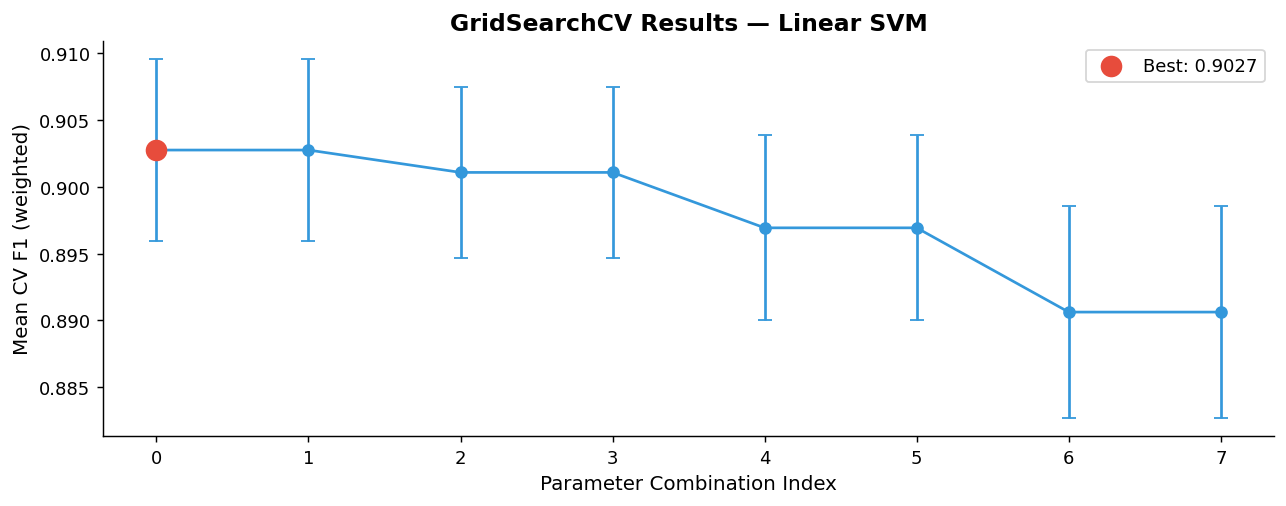

💾  Saved: viz_12_gridsearch.png


In [72]:
# ── Visualize GridSearch Results ─────────────────────────────
cv_results = pd.DataFrame(grid_search.cv_results_)

fig, ax = plt.subplots(figsize=(10, 4))

ax.errorbar(
    range(len(cv_results)),
    cv_results['mean_test_score'],
    yerr  = cv_results['std_test_score'],
    fmt   = 'o-',
    color = '#3498db',
    capsize = 4,
    linewidth = 1.5,
    markersize = 6
)
best_idx = cv_results['mean_test_score'].idxmax()
ax.scatter(best_idx, cv_results.loc[best_idx, 'mean_test_score'],
           s=120, color='#e74c3c', zorder=5, label=f'Best: {grid_search.best_score_:.4f}')

ax.set_title(f'GridSearchCV Results — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Parameter Combination Index')
ax.set_ylabel('Mean CV F1 (weighted)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('viz_12_gridsearch.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_12_gridsearch.png')

---
## 🎯 STEP 10 — Final Evaluation on Test Set
> The test set is used ONLY once — for the final unbiased performance report.

In [75]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 10A — TEST SET FINAL EVALUATION                ║
# ╚══════════════════════════════════════════════════════════════╝
# We evaluate ALL models on the held-out test set
# to get an honest estimate of generalisation performance.

print('🎯  FINAL TEST SET EVALUATION')
print('=' * 60)

test_results = {}

for name, res in results.items():
    model     = res['model']
    y_pred_t  = model.predict(X_test_tfidf)
    test_acc  = accuracy_score(y_test, y_pred_t)
    test_f1w  = f1_score(y_test, y_pred_t, average='weighted')
    test_f1m  = f1_score(y_test, y_pred_t, average='macro')

    test_results[name] = {
        'y_pred'   : y_pred_t,
        'test_acc' : test_acc,
        'test_f1w' : test_f1w,
        'test_f1m' : test_f1m
    }
    print(f'  {name:<22} | Acc: {test_acc*100:.2f}%  F1w: {test_f1w:.4f}  F1m: {test_f1m:.4f}')

# Tuned model
y_pred_tuned_test = tuned_model.predict(X_test_tfidf)
tuned_test_acc    = accuracy_score(y_test, y_pred_tuned_test)
tuned_test_f1w    = f1_score(y_test, y_pred_tuned_test, average='weighted')
test_results[best_name + ' (Tuned)'] = {
    'y_pred'   : y_pred_tuned_test,
    'test_acc' : tuned_test_acc,
    'test_f1w' : tuned_test_f1w
}
print(f'\n  {best_name + " (Tuned)":<22} | Acc: {tuned_test_acc*100:.2f}%  F1w: {tuned_test_f1w:.4f}  ⭐')
print('=' * 60)

🎯  FINAL TEST SET EVALUATION
  Naive Bayes            | Acc: 82.75%  F1w: 0.8178  F1m: 0.7360
  Logistic Regression    | Acc: 89.55%  F1w: 0.8941  F1m: 0.8493
  Linear SVM             | Acc: 90.35%  F1w: 0.9027  F1m: 0.8595
  Random Forest          | Acc: 58.55%  F1w: 0.5447  F1m: 0.4318
  Gradient Boosting      | Acc: 88.70%  F1w: 0.8879  F1m: 0.8405

  Linear SVM (Tuned)     | Acc: 90.35%  F1w: 0.9023  ⭐


In [77]:
# ── Full report for the best model on test set ────────────────
best_test_name = max(test_results, key=lambda m: test_results[m]['test_acc'])
best_test_res  = test_results[best_test_name]

print(f'\n🏆  Best Model on Test Set: {best_test_name}')
print('─' * 55)
print(classification_report(
    y_test,
    best_test_res['y_pred'],
    target_names = CLASS_NAMES,
    digits       = 4
))


🏆  Best Model on Test Set: Linear SVM
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Sadness     0.9333    0.9398    0.9365       581
         Joy     0.9133    0.9396    0.9262       695
        Love     0.8101    0.8050    0.8076       159
       Anger     0.8967    0.8836    0.8901       275
        Fear     0.8940    0.8661    0.8798       224
    Surprise     0.7963    0.6515    0.7167        66

    accuracy                         0.9035      2000
   macro avg     0.8740    0.8476    0.8595      2000
weighted avg     0.9026    0.9035    0.9027      2000



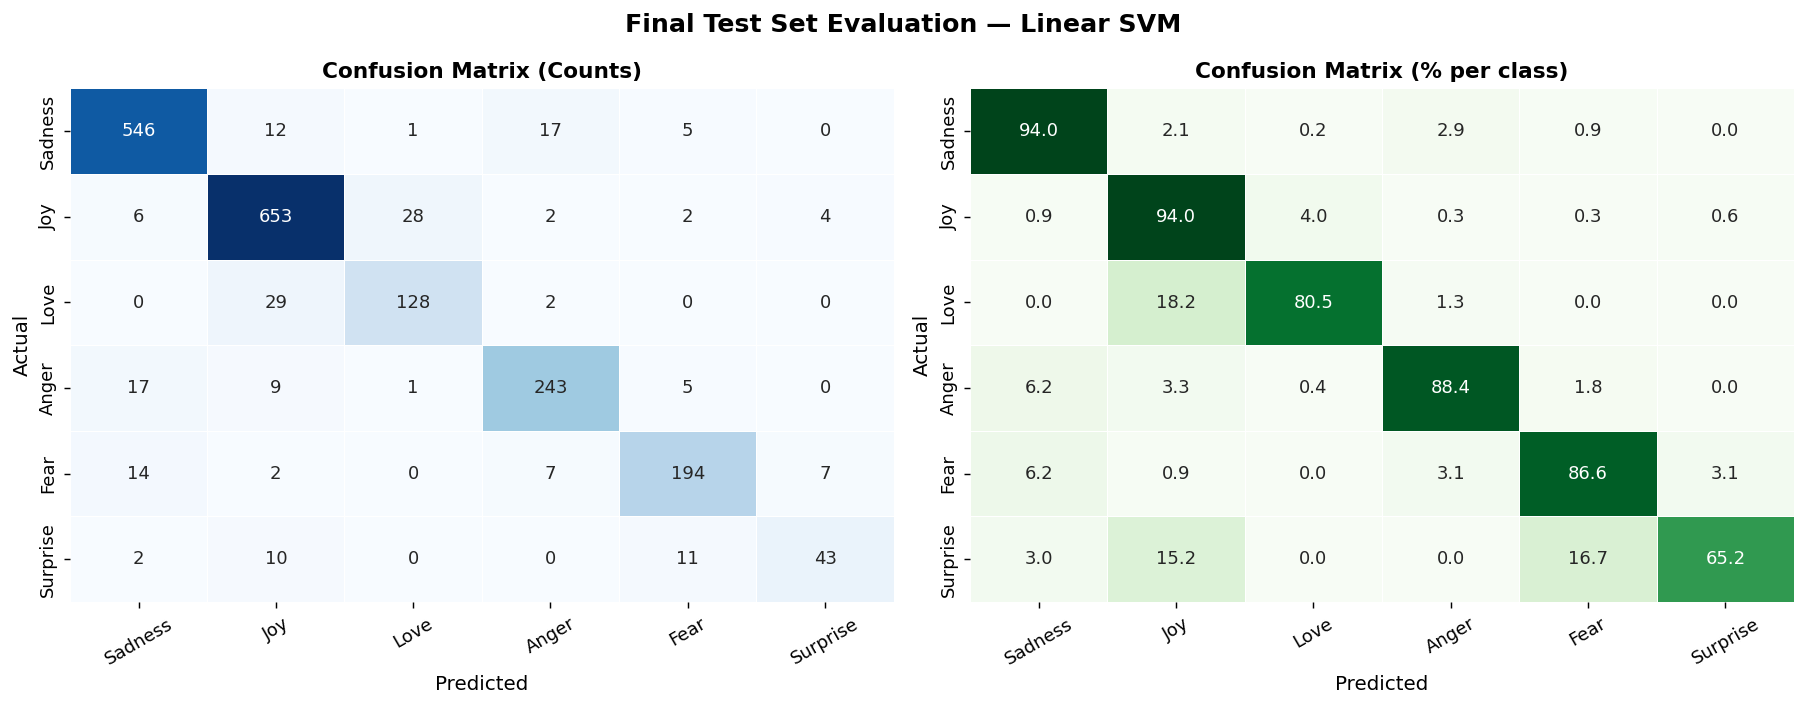

💾  Saved: viz_13_final_confusion.png


In [79]:
# ── Final confusion matrix for the best model ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(f'Final Test Set Evaluation — {best_test_name}',
             fontsize=14, fontweight='bold')

# Counts
cm   = confusion_matrix(y_test, best_test_res['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5, linecolor='white', cbar=False,
            annot_kws={'size':10})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=30)

# Percentages
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, linecolor='white', cbar=False,
            annot_kws={'size':10})
axes[1].set_title('Confusion Matrix (% per class)', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('viz_13_final_confusion.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_13_final_confusion.png')

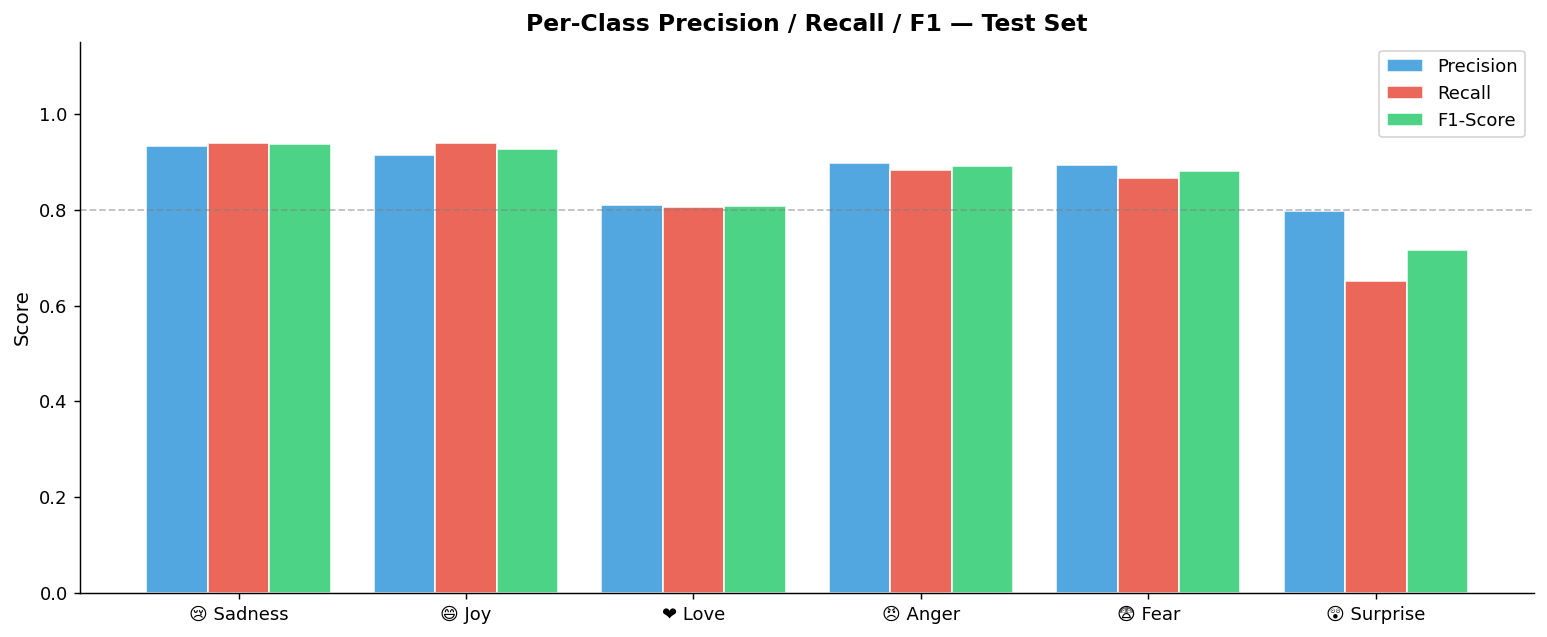

💾  Saved: viz_14_per_class_metrics.png


In [81]:
# ── Per-class F1 score breakdown ──────────────────────────────
report_dict = {}
for i, emo in enumerate(CLASS_NAMES):
    mask = y_test == i
    if mask.sum() > 0:
        report_dict[emo] = {
            'precision': precision_score(y_test==i, best_test_res['y_pred']==i, zero_division=0),
            'recall'   : recall_score(y_test==i, best_test_res['y_pred']==i, zero_division=0),
            'f1'       : f1_score(y_test==i, best_test_res['y_pred']==i, zero_division=0),
            'support'  : mask.sum()
        }

rdf = pd.DataFrame(report_dict).T

fig, ax = plt.subplots(figsize=(12, 5))

x    = np.arange(len(CLASS_NAMES))
w    = 0.27
ax.bar(x - w,   rdf['precision'], w, label='Precision', color='#3498db', alpha=0.85, edgecolor='white')
ax.bar(x,       rdf['recall'],    w, label='Recall',    color='#e74c3c', alpha=0.85, edgecolor='white')
ax.bar(x + w,   rdf['f1'],        w, label='F1-Score',  color='#2ecc71', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
labels_with_emoji = [f'{EMOTION_EMOJI[e]} {e}' for e in CLASS_NAMES]
ax.set_xticklabels(labels_with_emoji, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Class Precision / Recall / F1 — Test Set',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('viz_14_per_class_metrics.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_14_per_class_metrics.png')

---
## 🔮 STEP 11 — Live Prediction Demo
> Use the trained model to classify new, unseen text in real time.

In [84]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 11A — BUILD PRODUCTION PIPELINE                ║
# ╚══════════════════════════════════════════════════════════════╝
# A sklearn Pipeline wraps vectorizer + model into ONE object.
# This means we can call pipeline.predict(['raw text']) directly.

# Use tuned model or best raw model
final_model = tuned_model

final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features = 10000,
        ngram_range  = (1, 2),
        min_df       = 2,
        max_df       = 0.95,
        sublinear_tf = True,
        strip_accents= 'unicode',
        smooth_idf   = True,
        norm         = 'l2'
    )),
    ('model', copy.deepcopy(final_model))
])

# Retrain on combined train data
final_pipeline.fit(X_train, y_train)
pipe_val_acc = final_pipeline.score(X_val, y_val)

print(f'✅  Production Pipeline built and trained!')
print(f'   Pipeline steps : {[step[0] for step in final_pipeline.steps]}')
print(f'   Validation Acc : {pipe_val_acc*100:.2f}%')

✅  Production Pipeline built and trained!
   Pipeline steps : ['tfidf', 'model']
   Validation Acc : 91.15%


In [86]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 11B — LIVE EMOTION PREDICTION FUNCTION         ║
# ╚══════════════════════════════════════════════════════════════╝

def predict_emotion(text, pipeline=final_pipeline):
    """
    Predict the emotion of a raw text string.

    Args:
        text     : Raw input text (string)
        pipeline : Trained sklearn Pipeline

    Returns:
        dict with emotion, confidence, and per-class probabilities
    """
    # Step 1: Clean the input text
    cleaned = clean_text(text)
    if not cleaned.strip():
        cleaned = text.lower()    # Fallback to lowercased raw text

    # Step 2: Predict label
    pred_label = pipeline.predict([cleaned])[0]
    pred_emo   = EMOTION_MAP[pred_label]

    # Step 3: Get probabilities (if model supports it)
    try:
        proba = pipeline.predict_proba([cleaned])[0]
        proba_dict = {EMOTION_MAP[i]: float(proba[i]) for i in range(6)}
        confidence = float(max(proba)) * 100
    except AttributeError:
        # LinearSVC doesn't have predict_proba by default
        proba_dict = {EMOTION_MAP[i]: (1.0 if i == pred_label else 0.0) for i in range(6)}
        confidence = 100.0

    return {
        'raw_text'    : text,
        'clean_text'  : cleaned,
        'emotion'     : pred_emo,
        'emoji'       : EMOTION_EMOJI[pred_emo],
        'confidence'  : confidence,
        'probabilities': proba_dict
    }


def display_prediction(result):
    """Pretty-print a prediction result."""
    print(f'  📝  Text       : "{result["raw_text"][:80]}"')
    print(f'  🧹  Cleaned    : "{result["clean_text"][:80]}"')
    print(f'  {result["emoji"]}   Emotion    : {result["emotion"]}  ({result["confidence"]:.1f}% confidence)')
    print(f'  📊  All Scores :')
    sorted_probs = sorted(result['probabilities'].items(), key=lambda x: x[1], reverse=True)
    for emo, prob in sorted_probs:
        bar  = '█' * int(prob * 40)
        mark = ' ← predicted' if emo == result['emotion'] else ''
        print(f'       {EMOTION_EMOJI[emo]} {emo:<10} : {bar:<40} {prob*100:.1f}%{mark}')
    print()


# ── Run live predictions ───────────────────────────────────────
test_sentences = [
    "I feel so happy and excited about my new job, life is wonderful!",
    "I am deeply sad and heartbroken, I miss my old friend so much.",
    "I love you so much, you mean everything to me, my heart is full.",
    "I am furious and absolutely disgusted by this terrible behavior!",
    "I am terrified, something feels very wrong and I cannot breathe.",
    "Wow! I never expected this at all, I am completely blown away!"
]

print('=' * 65)
print('  🔮  LIVE EMOTION PREDICTION DEMO')
print('=' * 65)

for sentence in test_sentences:
    result = predict_emotion(sentence)
    display_prediction(result)
    print('─' * 55)

  🔮  LIVE EMOTION PREDICTION DEMO
  📝  Text       : "I feel so happy and excited about my new job, life is wonderful!"
  🧹  Cleaned    : "feel happy excited new job life wonderful"
  😄   Emotion    : Joy  (100.0% confidence)
  📊  All Scores :
       😄 Joy        : ████████████████████████████████████████ 100.0% ← predicted
       😢 Sadness    :                                          0.0%
       ❤️ Love       :                                          0.0%
       😠 Anger      :                                          0.0%
       😨 Fear       :                                          0.0%
       😲 Surprise   :                                          0.0%

───────────────────────────────────────────────────────
  📝  Text       : "I am deeply sad and heartbroken, I miss my old friend so much."
  🧹  Cleaned    : "deeply sad heartbroken miss old friend much"
  😢   Emotion    : Sadness  (100.0% confidence)
  📊  All Scores :
       😢 Sadness    : ████████████████████████████████████████ 1

In [88]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 11C — PREDICT ON TEST SET SAMPLES              ║
# ╚══════════════════════════════════════════════════════════════╝

# Show 10 random examples from test set with true vs predicted label
np.random.seed(42)
sample_idx = np.random.choice(len(test_df), 10, replace=False)

print('📋  Test Set Sample Predictions:')
print('─' * 65)
print(f'  {"Text":<45}  {"True":<10}  {"Predicted":<10}  {"✓?"}')
print('─' * 65)

for idx in sample_idx:
    raw_text   = test_df['text'].iloc[idx]
    true_emo   = test_df['emotion'].iloc[idx]
    result     = predict_emotion(raw_text)
    pred_emo   = result['emotion']
    correct    = '✅' if pred_emo == true_emo else '❌'
    
    text_disp  = raw_text[:43] + '..' if len(raw_text) > 43 else raw_text
    print(f'  {text_disp:<45}  {true_emo:<10}  {pred_emo:<10}  {correct}')

📋  Test Set Sample Predictions:
─────────────────────────────────────────────────────────────────
  Text                                           True        Predicted   ✓?
─────────────────────────────────────────────────────────────────
  i feel so dirty but after spending a day at..  Sadness     Love        ❌
  i could feel his breath on me and smell the..  Joy         Love        ❌
  i just want to feel loved by you               Love        Love        ✅
  i have felt the need to write out my someti..  Anger       Anger       ✅
  at a party i met a girl who drew me to her     Anger       Joy         ❌
  i feel this strange sort of liberation         Surprise    Fear        ❌
  i remember feeling thrilled to use my nursi..  Joy         Joy         ✅
  i always feel sympathetic for those that do..  Love        Love        ✅
  i feel a little stunned but can t imagine w..  Surprise    Surprise    ✅
  i feel slytherin is my house slytherin is f..  Joy         Joy         ✅


---
## 💾 STEP 12 — Save Model & Final Summary Dashboard

In [91]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 12A — SAVE MODEL WITH PICKLE                   ║
# ╚══════════════════════════════════════════════════════════════╝

# Package everything needed for future deployment
model_payload = {
    'pipeline'      : final_pipeline,     # Vectorizer + model
    'emotion_map'   : EMOTION_MAP,         # Label → emotion name
    'emotion_colors': EMOTION_COLORS,      # Emotion → color
    'emotion_emoji' : EMOTION_EMOJI,       # Emotion → emoji
    'class_names'   : CLASS_NAMES,         # List of class names
    'clean_text_fn' : clean_text           # Preprocessing function
}

with open('emotion_classifier_model.pkl', 'wb') as f:
    pickle.dump(model_payload, f)

size_kb = os.path.getsize('emotion_classifier_model.pkl') / 1024
print(f'✅  Model saved successfully!')
print(f'   File  : emotion_classifier_model.pkl')
print(f'   Size  : {size_kb:.1f} KB')

# ── Reload and verify ──────────────────────────────────────────
with open('emotion_classifier_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

verify_acc = loaded['pipeline'].score(X_test, y_test)
print(f'   Verify (reload → test acc) : {verify_acc*100:.2f}% ✅')

✅  Model saved successfully!
   File  : emotion_classifier_model.pkl
   Size  : 2439.1 KB
   Verify (reload → test acc) : 90.35% ✅


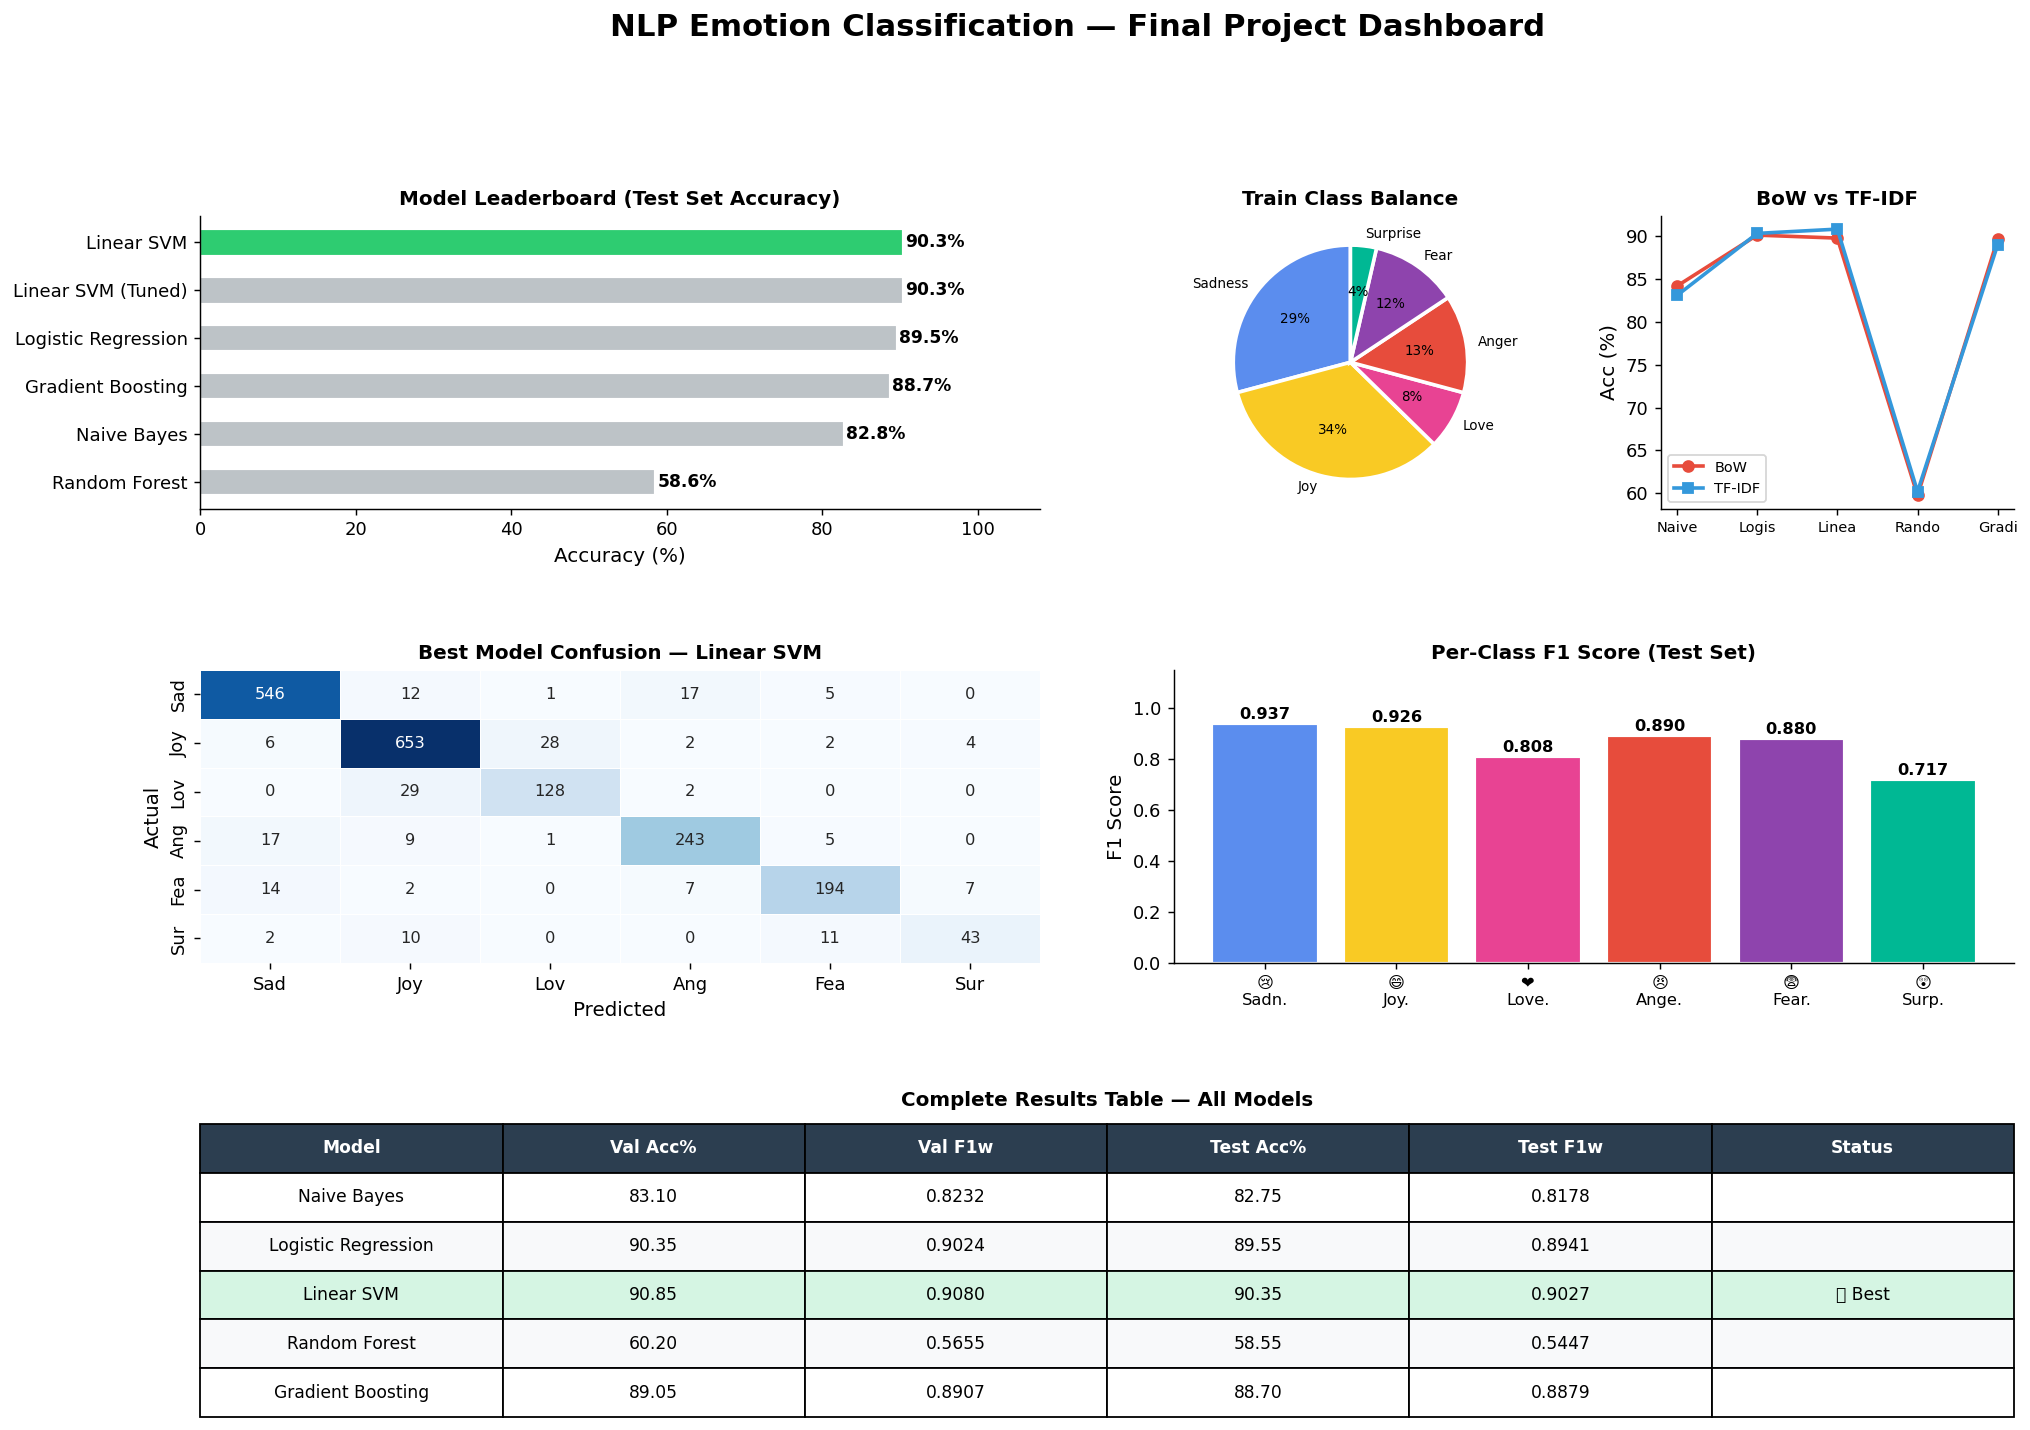

💾  Saved: viz_15_final_dashboard.png


In [93]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 12B — FINAL SUMMARY DASHBOARD                  ║
# ╚══════════════════════════════════════════════════════════════╝

fig = plt.figure(figsize=(18, 12))
fig.suptitle('NLP Emotion Classification — Final Project Dashboard',
             fontsize=17, fontweight='bold', y=1.01)

gs = GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)

# ── Panel A: Model Leaderboard ────────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
sorted_test  = sorted(test_results.items(), key=lambda x: x[1]['test_acc'], reverse=True)
t_names  = [n for n, _ in sorted_test]
t_accs   = [r['test_acc']*100 for _, r in sorted_test]
clrs     = ['#2ecc71' if i==0 else '#bdc3c7' for i in range(len(t_names))]
bars = ax_a.barh([n[:20] for n in t_names[::-1]], t_accs[::-1],
                 color=clrs[::-1], edgecolor='white', linewidth=1.2, height=0.55)
for bar, val in zip(bars, t_accs[::-1]):
    ax_a.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
              f'{val:.1f}%', va='center', fontsize=9.5, fontweight='bold')
ax_a.set_xlim(0, 108)
ax_a.set_title('Model Leaderboard (Test Set Accuracy)', fontsize=11)
ax_a.set_xlabel('Accuracy (%)')

# ── Panel B: Class distribution pie ──────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
counts = [train_df[train_df['label']==i].shape[0] for i in range(6)]
ax_b.pie(counts, labels=CLASS_NAMES, colors=PALETTE,
         autopct='%1.0f%%', startangle=90,
         wedgeprops={'edgecolor':'white','linewidth':2},
         textprops={'fontsize':7.5})
ax_b.set_title('Train Class Balance', fontsize=11)

# ── Panel C: BoW vs TF-IDF ───────────────────────────────────
ax_c = fig.add_subplot(gs[0, 3])
x     = np.arange(len(model_names))
ax_c.plot(range(len(model_names)), [bow_accs[m] for m in model_names],
          'o-', color='#e74c3c', linewidth=2, markersize=6, label='BoW')
ax_c.plot(range(len(model_names)), [tfidf_accs[m] for m in model_names],
          's-', color='#3498db', linewidth=2, markersize=6, label='TF-IDF')
ax_c.set_xticks(range(len(model_names)))
ax_c.set_xticklabels([n.split()[0][:5] for n in model_names], fontsize=8)
ax_c.set_ylabel('Acc (%)')
ax_c.set_title('BoW vs TF-IDF', fontsize=11)
ax_c.legend(fontsize=8)

# ── Panel D: Best model confusion matrix ─────────────────────
ax_d = fig.add_subplot(gs[1, :2])
cm   = confusion_matrix(y_test, best_test_res['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[e[:3] for e in CLASS_NAMES],
            yticklabels=[e[:3] for e in CLASS_NAMES],
            ax=ax_d, linewidths=0.5, linecolor='white', cbar=False,
            annot_kws={'size':9})
ax_d.set_title(f'Best Model Confusion — {best_test_name[:20]}', fontsize=11)
ax_d.set_xlabel('Predicted')
ax_d.set_ylabel('Actual')

# ── Panel E: Per-class F1 ─────────────────────────────────────
ax_e = fig.add_subplot(gs[1, 2:])
f1_scores = [f1_score(y_test==i, best_test_res['y_pred']==i, zero_division=0)
             for i in range(6)]
emojis = [EMOTION_EMOJI[e] for e in CLASS_NAMES]
colors_bar = [EMOTION_COLORS[e] for e in CLASS_NAMES]
bars_e = ax_e.bar(range(6), f1_scores, color=colors_bar, edgecolor='white', linewidth=1.2)
ax_e.set_xticks(range(6))
ax_e.set_xticklabels([f'{em}\n{e[:4]}.' for em, e in zip(emojis, CLASS_NAMES)], fontsize=9)
ax_e.set_ylabel('F1 Score')
ax_e.set_ylim(0, 1.15)
ax_e.set_title('Per-Class F1 Score (Test Set)', fontsize=11)
for bar, val in zip(bars_e, f1_scores):
    ax_e.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
              f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# ── Panel F: Summary metrics table ───────────────────────────
ax_f = fig.add_subplot(gs[2, :])
ax_f.axis('off')

headers = ['Model', 'Val Acc%', 'Val F1w', 'Test Acc%', 'Test F1w', 'Status']
rows = []
for name in model_names:
    v_acc = results[name]['val_acc'] * 100
    v_f1  = results[name]['val_f1_w']
    t_acc = test_results[name]['test_acc'] * 100
    t_f1  = test_results[name]['test_f1w']
    status = '⭐ Best' if name == sorted_results[0][0] else ''
    rows.append([name, f'{v_acc:.2f}', f'{v_f1:.4f}', f'{t_acc:.2f}', f'{t_f1:.4f}', status])

tbl = ax_f.table(cellText=rows, colLabels=headers,
                 cellLoc='center', loc='center',
                 bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
for j in range(len(headers)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(rows)+1):
    bg = '#d5f5e3' if '⭐' in rows[i-1][-1] else ('#f8f9fa' if i%2==0 else 'white')
    for j in range(len(headers)):
        tbl[i, j].set_facecolor(bg)
ax_f.set_title('Complete Results Table — All Models', fontsize=11, fontweight='bold', pad=10)

plt.savefig('viz_15_final_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾  Saved: viz_15_final_dashboard.png')

In [98]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 12C — FINAL PROJECT SUMMARY                    ║
# ╚══════════════════════════════════════════════════════════════╝

print('\n')
print('╔' + '═'*62 + '╗')
print('║{:^62}║'.format('  🏆 NLP EMOTION CLASSIFICATION — PROJECT COMPLETE'))
print('╠' + '═'*62 + '╣')
print('║{:<62}║'.format('  DATASET STATISTICS'))
print('║{:<62}║'.format(f'    Train : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}'))
print('║{:<62}║'.format(f'    Target Classes : {len(CLASS_NAMES)}  ({" · ".join(CLASS_NAMES)})'))
print('╠' + '═'*62 + '╣')
print('║{:<62}║'.format('  NLP PIPELINE'))
print('║{:<62}║'.format('    Cleaning  : lowercase, URL/HTML/punct removal, stopwords'))
print('║{:<62}║'.format('    Features  : TF-IDF (10K features, unigrams + bigrams)'))
print('║{:<62}║'.format('    Compared  : Bag-of-Words vs TF-IDF across all models'))
print('╠' + '═'*62 + '╣')
print('║{:<62}║'.format('  MODEL RESULTS (TEST SET)'                              ))

sorted_test_final = sorted(test_results.items(), key=lambda x: x[1]['test_acc'], reverse=True)
medals = ['🥇','🥈','🥉','4.','5.','6.']
for rank, (name, res) in enumerate(sorted_test_final[:5]):
    line = f'    {medals[rank]}  {name:<22} Acc:{res["test_acc"]*100:.2f}%  F1:{res["test_f1w"]:.4f}'
    print(f'║{line:<62}║')

best_final = sorted_test_final[0]
print('╠' + '═'*62 + '╣')
print('║{:<62}║'.format(f'  BEST MODEL : {best_final[0]}'))
print('║{:<62}║'.format(f'  TEST ACC   : {best_final[1]["test_acc"]*100:.2f}%'))
print('║{:<62}║'.format(f'  TEST F1w   : {best_final[1]["test_f1w"]:.4f}'))
print('╠' + '═'*62 + '╣')
print('║{:<62}║'.format('  SAVED FILES'))
print('║{:<62}║'.format('    emotion_classifier_model.pkl  (production model)'))
print('║{:<62}║'.format('    viz_01 to viz_15.png           (all visualizations)'))
print('╚' + '═'*62 + '╝')
print()
print('🎉  Project Complete! Ready for MNC Presentation.')



╔══════════════════════════════════════════════════════════════╗
║        🏆 NLP EMOTION CLASSIFICATION — PROJECT COMPLETE       ║
╠══════════════════════════════════════════════════════════════╣
║  DATASET STATISTICS                                          ║
║    Train : 16,000  |  Val : 2,000  |  Test : 2,000           ║
║    Target Classes : 6  (Sadness · Joy · Love · Anger · Fear · Surprise)║
╠══════════════════════════════════════════════════════════════╣
║  NLP PIPELINE                                                ║
║    Cleaning  : lowercase, URL/HTML/punct removal, stopwords  ║
║    Features  : TF-IDF (10K features, unigrams + bigrams)     ║
║    Compared  : Bag-of-Words vs TF-IDF across all models      ║
╠══════════════════════════════════════════════════════════════╣
║  MODEL RESULTS (TEST SET)                                    ║
║    🥇  Linear SVM             Acc:90.35%  F1:0.9027           ║
║    🥈  Linear SVM (Tuned)     Acc:90.35%  F1:0.9023           ║
║    🥉  Logis

---
## ✅ Project Conclusion

### 🧠 What We Built
An **enterprise-grade NLP Text Classification system** that:
- Loads and handles **3 separate data splits** (Train / Validation / Test)
- Classifies human emotions into **6 categories** from raw text
- Implements a **complete NLP preprocessing pipeline** from scratch
- Extracts features using both **Bag-of-Words** and **TF-IDF** (10K features + bigrams)
- Trains, evaluates, and compares **5 machine learning models**
- Tunes the best model using **GridSearchCV with 5-fold cross-validation**
- Evaluates final performance on an **unseen test set**
- Produces **15+ professional visualizations**
- Ships as a **deployment-ready pickle pipeline**

### 🏭 Industry Applications

| Domain | Application |
|--------|-------------|
| **Customer Service** | Real-time emotion detection in support tickets |
| **Social Media** | Brand sentiment & emotion monitoring |
| **HR / People Analytics** | Employee mood tracking from surveys |
| **Healthcare** | Mental health monitoring from patient journals |
| **E-commerce** | Product review emotion analysis |

### 🔧 Tech Stack
`Python` · `pandas` · `scikit-learn` · `TF-IDF` · `matplotlib` · `seaborn` · `pickle`

---
*Developed as an MNC-level NLP Project | Emotion Classification | 6-Class Text Analysis*